
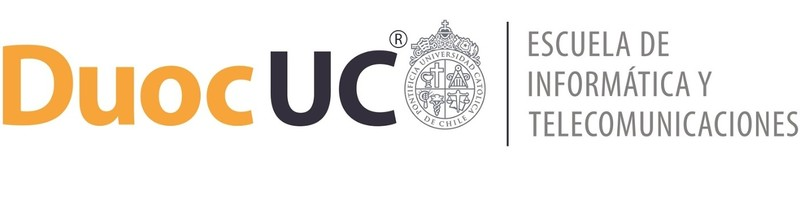

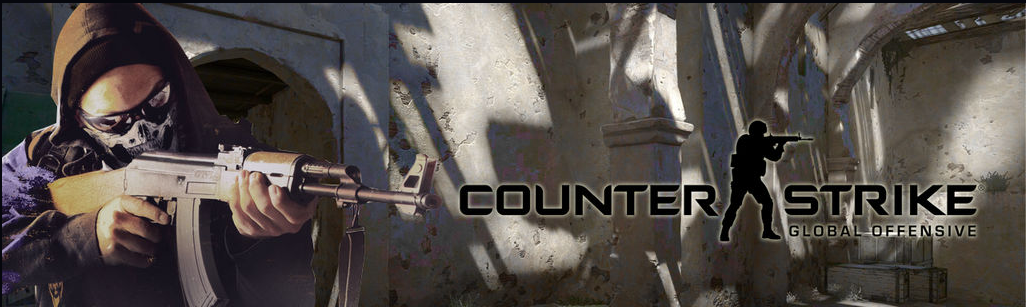

# Informe Técnico - Examen Transversal: Caso Counter Strike


Integrantes:
* Daniel Díaz
* Javier González

Docente:Francia Berna     

Sección: FMY0100 - 002D

# Caso Fundamentos de Machine Learning

CONTEXTO CASO

Valve, los ha contactado como equipo de análisis de datos y modelado de Machine Learning para analizar y realizar modelos predictivos sobre los datos.

En cada partida de Counter Strike: GO dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan.


El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Los datos a utilizar corresponden a sobre 7000 partidas del juego (con un máximo de 10 jugadores c/u)  


Los datos han sido extraídos de replays, los cuales son archivos propietarios con la información de cada una de las acciones realizadas por cada jugador dentro de una partida. Los replays han sido extraídos de la red utilizando un scrapper y pre-procesados utilizando un script.  



En este caso, la data corresponde a un archivo CSV con 79.157 filas, cada una correspondiente a un jugador dentro de una partida. El archivo contiene 29 columnas correspondientes a variables que describen las acciones del jugador dentro del juego.


$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline Map & \text {Nombre  del Mapa donde se jugó la partida}  \\
\hline \text{ Team} & \text { Nombre de equipo al que pertenece el jugador} \\
\hline \text{ InternalTeamId} & \text { Identificador del equipo al que pertenece el jugador.} \\
\hline \text{ MatchId} & \text { Identificador de la partida.} \\
\hline \text{ RoundId} & \text { Identificador de la ronda (los equipos se enfrentan en rondas de 5 partidas seguidas)} \\
\hline \text{ MatchWinner} & \text { Indica si el jugador ganó o no la partida.} \\
\hline \text{ RoundWinner} & \text { Indica si el jugador ganó o no la ronda analizada.} \\
\hline \text{ Survived} & \text { Indica si el jugador sobrevivió o no a la partida (sobrevivir no es sinónimo de ganar).} \\
\hline \text{ AbnormalMatch} & \text { Indica si la partida del jugador tuvo un error por conexión de red} \\
\hline \text{ TimeAlive} & \text { Indica el tiempo en segundos que el jugador estuvo vivo durante el juego} \\
\hline \text{ TravelledDistance} & \text { Distancia viajada por el jugador durante la partida.} \\
\hline \text{ RLethalGrenadesThrown/RNonLethalGrenadesThrown} & \text { Cantidad de granadas lanzadas, categorizadas en letales y no-letales.} \\
\hline \text{ PrimaryXXXX} & \text { Porcentaje de uso arma clasificada como primaria. Categorizada en AssaultRifle, SniperRifle, SMG, Heavy y Pistol.} \\
\hline \text{ [Match|Round] Assists} & \text { Cantidad de asistencias efectuadas por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] Kills} & \text { Cantidad de kills efectuados por el jugador durante la partida o la ronda.} \\
\hline \text{ [Match|Round] FlankKills} & \text { Cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.} \\
\hline \text{ [Match|Round] HeadShots} & \text { Cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.} \\
\hline \text{ RoundStartingEquipmentValue} & \text { Valor del equipamiento llevado por el jugador al inicio de la ronda.} \\
\hline \text{ TeamStartingEquipmentValue} & \text { Valor promedio del equipamiento llevado por el equipo del jugador al inicio de la ronda.} \\
\end{array}
\end{aligned}
$$

## Fase 1: Business Understanding

**Contexto de negocio**
Counter Strike es un videojuego de disparos en primera persona, donde en cada partida dos equipos de 5 jugadores (denominados terroristas y contra-terroristas) se enfrentan. Cada partida se compone de 30 rondas, donde el ganador de la partida es el primer equipo en ganar 16 rondas (a no ser que el otro equipo decida rendirse). Cada equipo se le asigna el papel de terroristo o contra-terrorista de forma aleatoria y estos solo son rotados después de la ronda n°15.

El objetivo del equipo terrorista es plantar una bomba con timer de 45 segundos en uno de dos sitios específicos dentro de un mapa. Por otro lado, el objetivo del equipo contra-terrorista es evitar que la bomba sea plantada o desactivarla antes de que esta explote cuando ya ha sido plantada. Una tercera forma de ganar que está disponible para ambos equipos es eliminar al resto de jugadores del equipo rival.

Durante el transcurso de una ronda, cada jugador es recompensado con dinero dependiendo de sus acciones en el juego (por ejemplo: plantar o desactivar la bomba otorga 300 dólares al jugador que lo hizo). Este dinero puede ser utilizado en una tienda virtual al comienzo de la siguiente ronda en varios tipos de equipamiento como armadura, armas con diferentes atributos, granadas, etc.

Los datos a utilizar corresponden a más de 7000 partidas del juego.


La pregunta que se va a intentar responder en este informe es: ¿Cómo afecta la cantidad de kills por headshots y kills por flanqueo al total de kills por partida y cuál de estos dos estilo de juego da mejores resultados?

La idea de responder esta pregunta es poder ayudar a un equipo profesional del juego a tomar mejores decisiones al momento de jugar e intentar lograr la mayor cantidad de kills, ya que tener más cantidad de kills aumenta las probabilidades de ganar del equipo.

**Variables relevantes para el caso:**

*   MatchKills (o muertes por partida) : Variable cuantitativa discreta, indica la cantidad de kills efectuados por el jugador durante la partida o la ronda.
*   MatchHeadshots (o disparos a la cabeza por partida): Variable cuantitativa discreta, indica la cantidad de kills efectuados por el jugador a través de un tiro en la cabeza durante la partida o la ronda.
*   MatchFlanKills (o muertes por flanqueo por partida): Variable cuantitativa discreta, indica la cantidad de kills efectuados por el jugador sin que la víctima lo viese durante la partida o la ronda.

En el informe anterior se encontró que no había correlación entre las variables de interés iniciales (valor del equipamiento, el valor de equipamiento del equipo y tiempo vivo), para este informe cambiamos de hipótesis y variables de interés a las que se mencionaron anteriormente, ya que se encontró que éstas sí tienen correlación de acuerdo al siguiente mapa de calor.

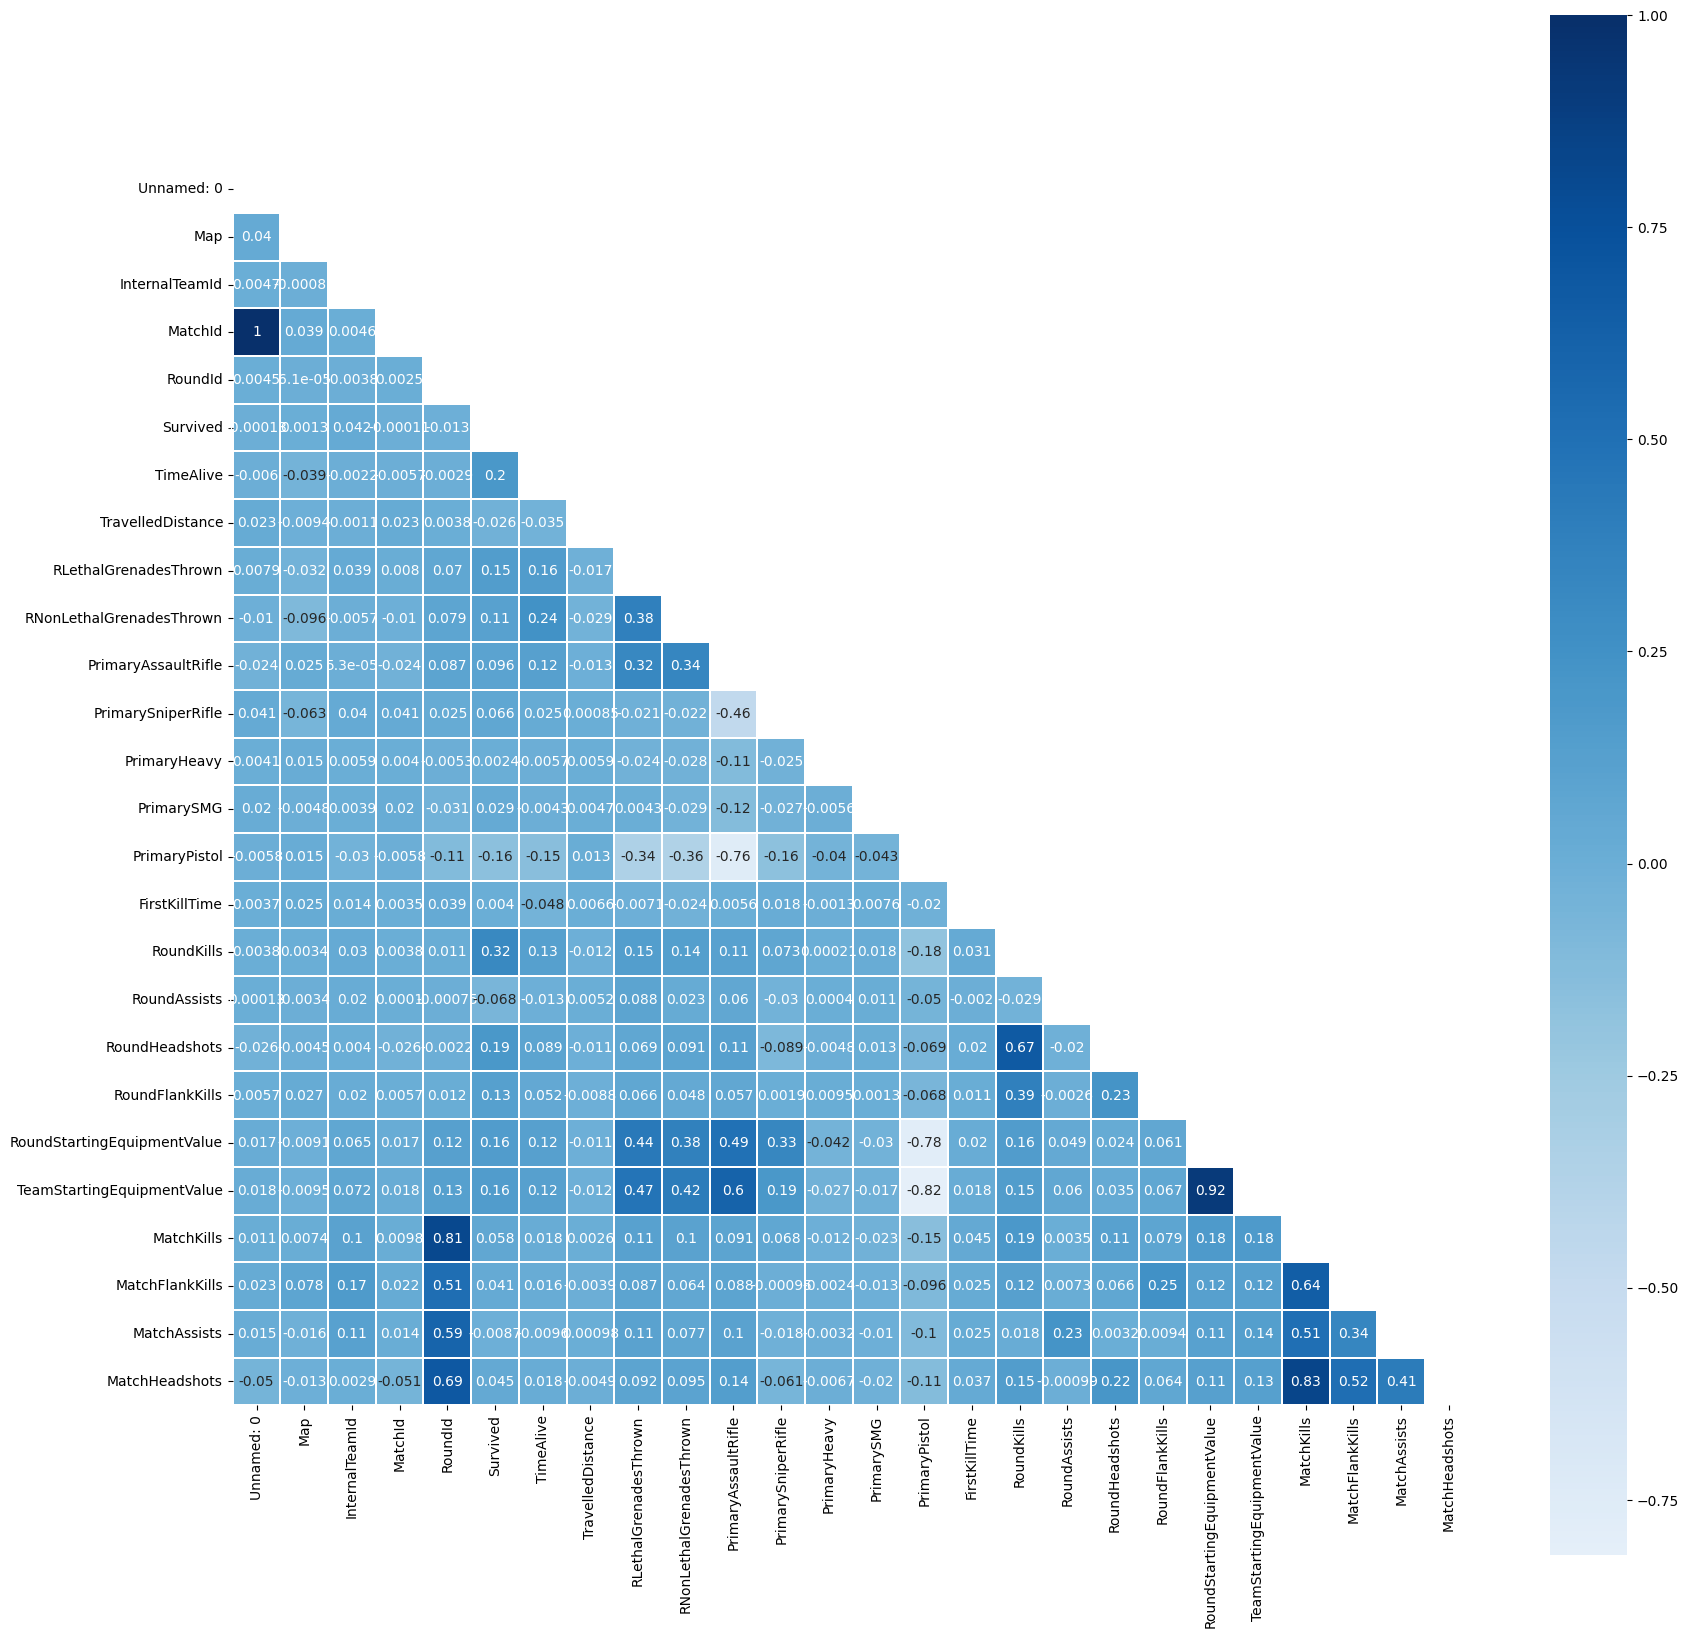

## Fase 2: Data Understanding

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# importación de funciones
from seaborn import scatterplot
from seaborn import boxplot

!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
# Carga de dataset desde google drive

#importaciones para cargar el archivo desde Google Drive
!pip install -U -q PyDrive

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Autenticacion de google drive
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#Enlace del archivo csv
link = 'https://drive.google.com/file/d/1jhDkmW8WC-I2e6eFfM1Oh0KUQtdgsEZB/view?usp=drive_link'
id = link.split("/")[-2]
downloaded = drive.CreateFile({'id':id})
#nombre del archivo
downloaded.GetContentFile('Informe_Tecnico_Examen ML',)
#Este archivo usa ";" como separador de columnas
df = pd.read_csv('Informe_Tecnico_Examen ML', sep=";")

<ipython-input-211-f29ee4acfde4>:24: DtypeWarning:

Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.



### Exploración

In [ ]:
print("El dataset se compone de {0} filas y {1} columnas".format(df.shape[0], df.shape[1]))

El dataset se compone de 79157 filas y 30 columnas


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79157 entries, 0 to 79156
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   79157 non-null  int64  
 1   Map                          79157 non-null  object 
 2   Team                         79155 non-null  object 
 3   InternalTeamId               79157 non-null  int64  
 4   MatchId                      79157 non-null  int64  
 5   RoundId                      79157 non-null  int64  
 6   RoundWinner                  79157 non-null  object 
 7   MatchWinner                  79156 non-null  object 
 8   Survived                     79157 non-null  bool   
 9   AbnormalMatch                79157 non-null  bool   
 10  TimeAlive                    79157 non-null  object 
 11  TravelledDistance            79157 non-null  object 
 12  RLethalGrenadesThrown        79157 non-null  int64  
 13  RNonLethalGrenad

In [ ]:
# Columnas con datos nulos
df.columns[df.isnull().any()]

Index(['Team', 'MatchWinner'], dtype='object')

In [ ]:
valores_faltantes = df.isnull().sum().sum()

total = df["TimeAlive"].count()

porcentaje = valores_faltantes*100/total

print("Cantidad de datos nulos: ", valores_faltantes)
print("Porcentaje de datos nulos: ", porcentaje, "%")

Cantidad de datos nulos:  3
Porcentaje de datos nulos:  0.0037899364553987645 %


A través de estos dos últimos métodos se puede ver que hay 2 filas con datos nulos en la columna Team y 1 en la columna MatchWinner, como esta cantidad de datos es tan pequeña respecto del total (solo un 0.003% del total), decidimos eliminarlos en la Fase 3.

In [ ]:
df.head(10)

,Unnamed: 0,Map,Team,InternalTeamId,MatchId,RoundId,RoundWinner,MatchWinner,Survived,AbnormalMatch,...,RoundKills,RoundAssists,RoundHeadshots,RoundFlankKills,RoundStartingEquipmentValue,TeamStartingEquipmentValue,MatchKills,MatchFlankKills,MatchAssists,MatchHeadshots
0,600,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,750,4400,0,0,0,0
1,601,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,800,4400,0,0,0,0
2,602,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,1000,4400,0,0,0,0
3,603,de_inferno,Terrorist,1,4,1,False,True,False,False,...,0,0,0,0,850,4400,0,0,0,0
4,604,de_inferno,Terrorist,1,4,1,False,True,True,False,...,0,0,0,0,1000,4400,0,0,0,0
5,605,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,850,3750,0,0,0,0
6,606,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,0,0,0,400,3750,0,0,0,0
7,607,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,0,1,0,0,800,3750,0,0,1,0
8,608,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,3,0,1,1,850,3750,3,1,0,1
9,609,de_inferno,CounterTerrorist,2,4,1,True,False,True,False,...,2,0,2,0,850,3750,2,0,0,2


**Exploración de la cantidad de kills por partida**

In [ ]:
df['MatchKills'].describe()

count    79157.000000
mean         8.511578
std          6.195079
min          0.000000
25%          3.000000
50%          8.000000
75%         13.000000
max         41.000000
Name: MatchKills, dtype: float64

In [ ]:
moda = df['MatchKills'].mode()
print(moda)

0    2
Name: MatchKills, dtype: int64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por jugador
calculo = 6.19/8.51*100
print("Coeficiente de variación para la cantidad de kills por partida: " ,calculo)

Coeficiente de variación para la cantidad de kills por partida:  72.737955346651


Número de kills durante una partida: estadística descriptiva.


*    Media: En promedio, los jugadores realizan 8,51 kills durante una partida
*   Moda: El registro de kills  mas frecuente durante una partida es de 2
*   Mediana: El 50% de los jugadores realizan sobre 8 kills durante una partida
*   Mínimo: Al finalizar la ronda, el registro de kills mas bajo es de 0
*   Máximo: Al finalizar la ronda, el registro de kills mas alto es de 41
*   Desv. estándar: 6,49
* Coeficiente de variación: (72,73%) Los valores de kills estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchKills', ylabel='Count'>

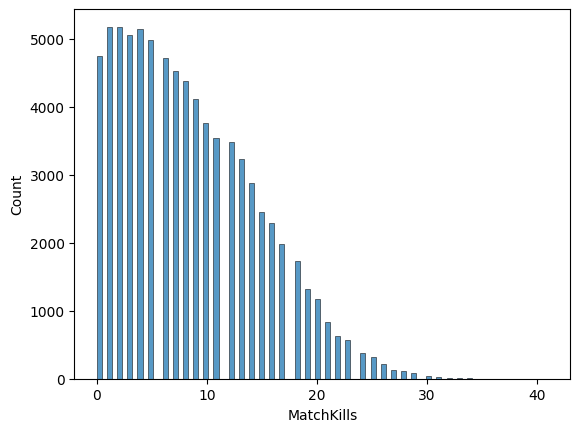

In [ ]:
sns.histplot(df['MatchKills'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por partida tiene un sesgo hacia la derecha o positivo y se observa una concentración de los datos debajo de 10.

<Axes: xlabel='MatchKills'>

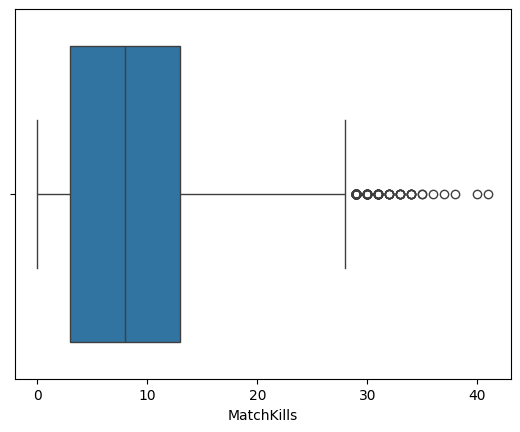

In [ ]:
boxplot(x="MatchKills", data=df)

Se encontraron valores atipicos sobre las 27 kills.

**Exloracion de cantidad de kills por flanqueo**

In [ ]:
df['MatchFlankKills'].describe()

count    79157.000000
mean         1.209912
std          1.435150
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max         11.000000
Name: MatchFlankKills, dtype: float64

In [ ]:
moda = df['MatchFlankKills'].mode()
print(moda)

0    0
Name: MatchFlankKills, dtype: int64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por equipos
calculo = 1.43/1.20*100
print("Coeficiente de variación para la cantidad de kills por flanqueo",calculo)

Coeficiente de variación para la cantidad de kills por flanqueo 119.16666666666667


Número de kills por flanqueo durante una partida: estadística descriptiva.


*   Media: En promedio, los jugadores realizan 1,20 kills por flanqueo durante una partida
*   Moda: El registro de kills por flanqueo mas frecuente durante una partida es de 0
*   Mediana: El 50% de los jugadores realizan sobre 1 kills por flanqueo durante una partida
*   Mínimo: Al finalizar la ronda, el registro de kills por flanqueo mas bajo es de 0
*   Máximo: Al finalizar la ronda, el registro de kills por headshots mas alto es de 11
*   Desv. estándar: 1,43
* Coeficiente de variación: (119,16%) Los valores de kills por flanqueo  estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchFlankKills', ylabel='Count'>

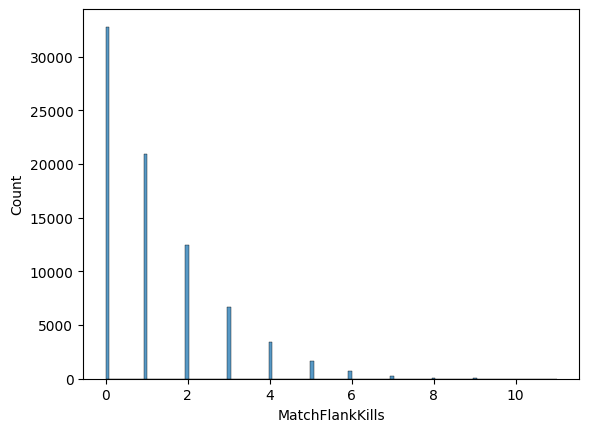

In [ ]:
sns.histplot(df['MatchFlankKills'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por flanqueo tiene sesgo hacia la derecha o positivo y tiene una gran concentración de datos alrededor de 0.  

<Axes: xlabel='MatchFlankKills'>

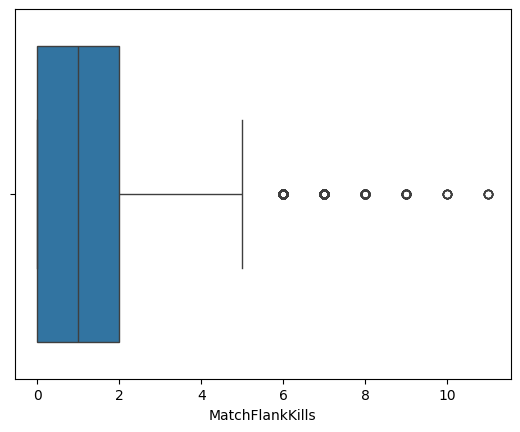

In [ ]:
boxplot(x="MatchFlankKills", data=df)

Se encontrarron valores atipicos sobre las 5 kills con flanqueo.

**Exloracion de cantidad de headshots por partida**

In [ ]:
df['MatchHeadshots'].describe()

count    79157.000000
mean         3.858484
std          3.246752
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         22.000000
Name: MatchHeadshots, dtype: float64

In [ ]:
moda = df['MatchHeadshots'].mode()
print(moda)

0    1
Name: MatchHeadshots, dtype: int64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por equipos
calculo = 3.24/3.85*100
print("Coeficiente de variación para la cantidad de kills por headshots",calculo)

Coeficiente de variación para la cantidad de kills por headshots 84.15584415584416


Número de kills por headshots durante una partida: estadística descriptiva.


*   Media: En promedio, los jugadores realizan 3,85 kills por headshots durante una partida
*   Moda: El registro de kills por headshots mas frecuente durante una partida es de 1
*   Mediana: El 50% de los jugadores realizan sobre 3 kills por headshots en una partida
*   Mínimo: Al finalizar la partida, el registro de kills por headshots mas bajo es de 0
*   Máximo: Al finalizar la partida, el registro de kills por headshots mas alto es de 22
*   Desv. estándar: 3,24
* Coeficiente de variación: (84,15%) Los valores de kills por headshots  estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchHeadshots', ylabel='Count'>

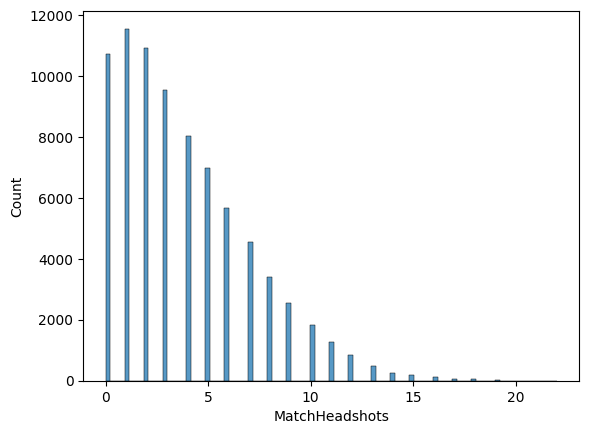

In [ ]:
sns.histplot(df['MatchHeadshots'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por headshots tiene sesgo hacia la derecha o positivo y tiene una gran concentración de datos debajo de 5 .  

<Axes: xlabel='MatchHeadshots'>

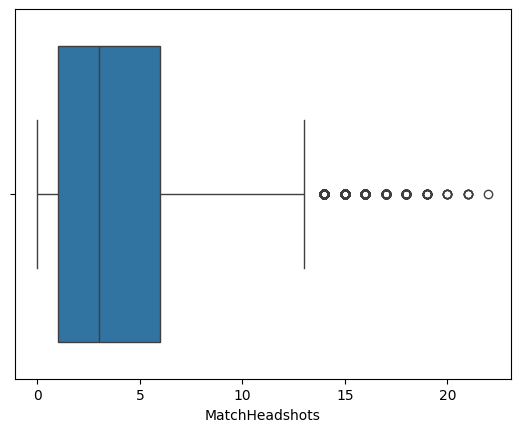

In [ ]:
boxplot(x="MatchHeadshots", data=df)

Se encontrarron valores atipicos sobre las 13 kills con headshots.

## Fase 3: Data Preparation

Como se mencionó anteriormente, hay 3 filas con datos nulos en 3 columnas, como esta cantidad de datos es tan pequeña respecto del total (solo un 0.003% del total), estas filas serán borradas a continuación.

In [ ]:
# Eliminación de filas con datos vacíos
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79154 entries, 0 to 79156
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   79154 non-null  int64  
 1   Map                          79154 non-null  object 
 2   Team                         79154 non-null  object 
 3   InternalTeamId               79154 non-null  int64  
 4   MatchId                      79154 non-null  int64  
 5   RoundId                      79154 non-null  int64  
 6   RoundWinner                  79154 non-null  object 
 7   MatchWinner                  79154 non-null  object 
 8   Survived                     79154 non-null  bool   
 9   AbnormalMatch                79154 non-null  bool   
 10  TimeAlive                    79154 non-null  object 
 11  TravelledDistance            79154 non-null  object 
 12  RLethalGrenadesThrown        79154 non-null  int64  
 13  RNonLethalGrenadesThr

Después de esta eliminación, ya no hay faltantes y todas las columnas tienen la misma cantidad de datos

**Outliers en la variable MatchKills**

A continuación se decidirá como tratar a los outliers en la varible MatchKills

In [ ]:
#Como se menciono anteriormente, se encontraron outliers sobre las 27 kills
outliers = (df["MatchKills"] > 27).sum()

total = df["MatchKills"].count()

porcentaje = outliers*100/total

print("Cantidad de outliers: ", outliers)
print("Porcentaje de outliers: ", porcentaje, "%")

Cantidad de outliers:  275
Porcentaje de outliers:  0.3474240088940546 %


A partir de esto, podemos afirmar que un 0,34% de estos datos son outliers. Si bien tiene sentido que estos datos existan de acuerdo al contexto del caso, estos datos seran imputados por la media ya que solo son el 0,34% del total de los datos.

<Axes: xlabel='MatchKills'>

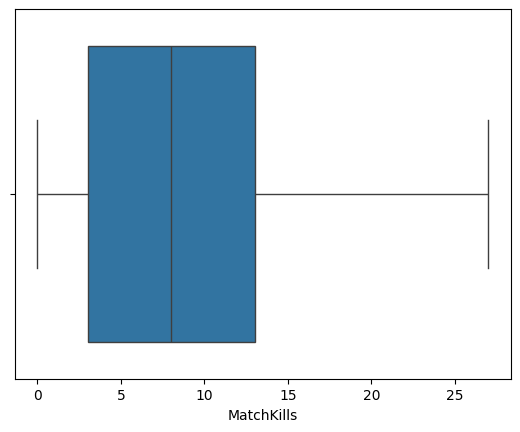

In [ ]:
#Imputación de los outliers
media = df["MatchKills"].mean()

df["MatchKills"] = df["MatchKills"].apply(lambda x: media if x > 27 else x)
boxplot(x="MatchKills", data=df)

A partir de la imputación de los outliers, ya no se osbservan datos atipicos en esta variable.

**Outliers en la variable MatchFlankKills**

A continuación se decidirá como tratar a los outliers en la varible MatchFlankKills

In [ ]:
#Como se menciono anteriormente, se encontraron outliers sobre las 5 kills con flanqueo
outliers = (df["MatchFlankKills"] > 5).sum()

total = df["MatchFlankKills"].count()

porcentaje = outliers*100/total

print("Cantidad de outliers: ", outliers)
print("Porcentaje de outliers: ", porcentaje, "%")

Cantidad de outliers:  1184
Porcentaje de outliers:  1.495818278292948 %


A partir de esto, podemos afirmar que un 1,49% de estos datos son outliers. Si bien tiene sentido que estos datos existan de acuerdo al contexto del caso, estos datos seran imputados por la media ya que solo son el 1,49% del total de los datos.

<Axes: xlabel='MatchFlankKills'>

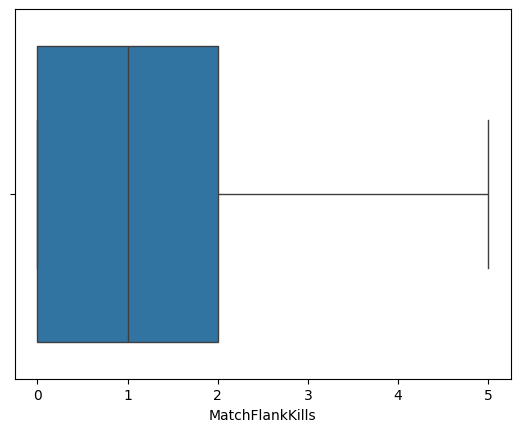

In [ ]:
#Imputación de los outliers
media = df["MatchFlankKills"].mean()

df["MatchFlankKills"] = df["MatchFlankKills"].apply(lambda x: media if x > 5 else x)
boxplot(x="MatchFlankKills", data=df)

Después de esta imputación. ya no se encuentran datos atípicos en MatchFlankKills

**Outliers en la variable MatchHeadshots**

A continuación se decidirá como tratar a los outliers en la varible MatchHeadshots

In [ ]:
#Como se menciono anteriormente, se encontraron outliers sobre las 13 kills con headshots
outliers = (df["MatchHeadshots"] > 13).sum()

total = df["MatchHeadshots"].count()

porcentaje = outliers*100/total

print("Cantidad de outliers: ", outliers)
print("Porcentaje de outliers: ", porcentaje, "%")

Cantidad de outliers:  724
Porcentaje de outliers:  0.9146726634156201 %


A partir de esto, podemos afirmar que un 0,91% de estos datos son outliers. Si bien tiene sentido que estos datos existan de acuerdo al contexto del caso, estos datos seran imputados por la media ya que solo son el 0,91% del total de los datos.

<Axes: xlabel='MatchHeadshots'>

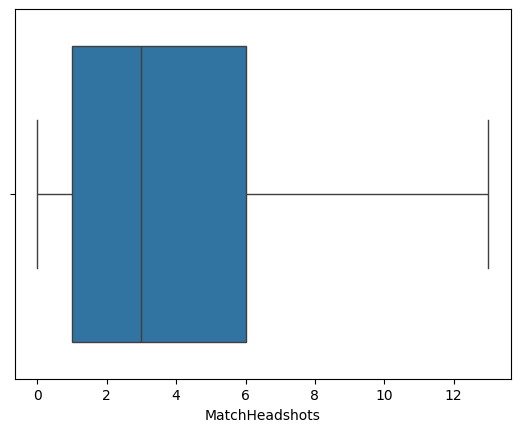

In [ ]:
#Imputación de los outliers
media = df["MatchHeadshots"].mean()

df["MatchHeadshots"] = df["MatchHeadshots"].apply(lambda x: media if x > 13 else x)
boxplot(x="MatchHeadshots", data=df)

### Segunda exploración de los datos


Como se imputó una cantidad considerable de filas, se volverá a analizar las variables por la posibilidad de que los valores de la estadística descriptiva hayan cambiado.

**Segunda exploración de la cantidad de kills por partida**

In [ ]:
df['MatchKills'].describe()

count    79154.000000
mean         8.439457
std          6.070574
min          0.000000
25%          3.000000
50%          8.000000
75%         13.000000
max         27.000000
Name: MatchKills, dtype: float64

In [ ]:
moda = df['MatchKills'].mode()
print(moda)

0    2.0
Name: MatchKills, dtype: float64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por jugador
calculo = 6.07/8.43*100
print("Coeficiente de variación para la cantidad de kills por partida: " ,calculo)

Coeficiente de variación para la cantidad de kills por partida:  72.00474495848161


Número de kills durante una partida: estadística descriptiva.


*  Media: En promedio, los jugadores realizan 8,43 kills durante una partida
*   Moda: El registro de kills  mas frecuente durante una partida es de 2
*   Mediana: El 50% de los jugadores realizan sobre 8 kills durante una partida
*   Mínimo: Al finalizar la ronda, el registro de kills mas bajo es de 0
*   Máximo: Al finalizar la ronda, el registro de kills mas alto es de 27
*   Desv. estándar: 6,07
* Coeficiente de variación: (72%) Los valores de kills estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchKills', ylabel='Count'>

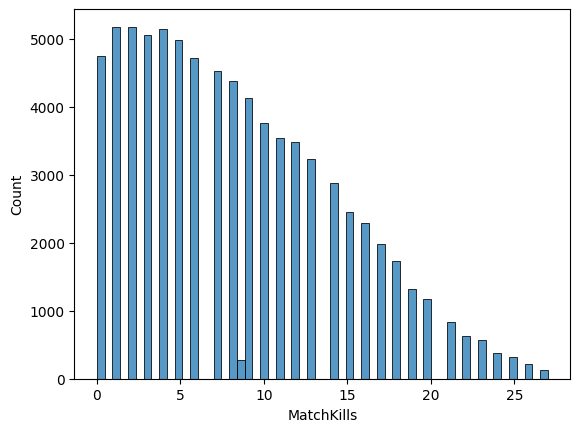

In [ ]:
sns.histplot(df['MatchKills'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por partida mantiene el sesgo que tenía anteriormente y aún se observa una concentración de los datos debajo de 10.

**Segunda exloracion de cantidad de kills por flanqueo**

In [ ]:
df['MatchFlankKills'].describe()

count    79154.000000
mean         1.130601
std          1.273424
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: MatchFlankKills, dtype: float64

In [ ]:
moda = df['MatchFlankKills'].mode()
print(moda)

0    0.0
Name: MatchFlankKills, dtype: float64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por equipos
calculo = 1.27/1.13*100
print("Coeficiente de variación para la cantidad de kills por flanqueo",calculo)

Coeficiente de variación para la cantidad de kills por flanqueo 112.38938053097347


Número de kills por flanqueo durante una partida: estadística descriptiva.

*   Media: En promedio, los jugadores realizan 1,13 kills por flanqueo durante una partida
*   Moda: El registro de kills por flanqueo mas frecuente durante una partida es de 0
*   Mediana: El 50% de los jugadores realizan sobre 1 kills por flanqueo durante una partida
*   Mínimo: Al finalizar la ronda, el registro de kills por flanqueo mas bajo es de 0
*   Máximo: Al finalizar la ronda, el registro de kills por headshots mas alto es de 5
*   Desv. estándar: 1,27
* Coeficiente de variación: (112,38%) Los valores de kills por flanqueo  estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchFlankKills', ylabel='Count'>

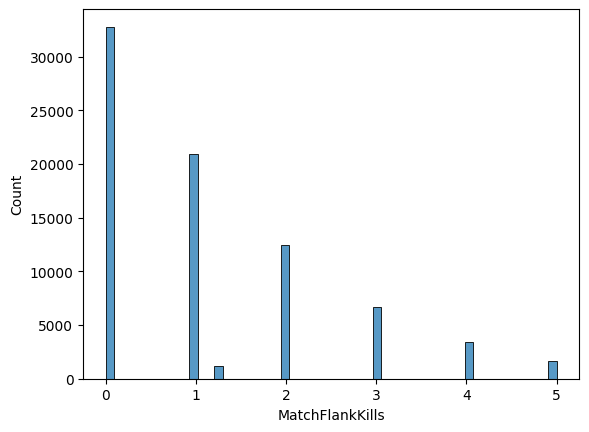

In [ ]:
sns.histplot(df['MatchFlankKills'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por flanqueo mantiene el sesgo que tenía antes de las imputaciones y sigue  concentrado alrededor de 0 kills.  

**Segunda exloracion de cantidad de headshots por partida**

In [ ]:
df['MatchHeadshots'].describe()

count    79154.000000
mean         3.753413
std          3.049670
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         13.000000
Name: MatchHeadshots, dtype: float64

In [ ]:
moda = df['MatchHeadshots'].mode()
print(moda)

0    1.0
Name: MatchHeadshots, dtype: float64


In [ ]:
# Coeficiente de variación para el valor de equipamiento por equipos
calculo = 3.04/3.75*100
print("Coeficiente de variación para la cantidad de kills por headshots",calculo)

Coeficiente de variación para la cantidad de kills por headshots 81.06666666666666


Número de kills por headshots durante una partida: estadística descriptiva.


*   Media: En promedio, los jugadores realizan 3,75 kills por headshots durante una partida
*   Moda: El registro de kills por headshots mas frecuente durante una partida es de 1
*   Mediana: El 50% de los jugadores realizan sobre 3 kills por headshots en una partida
*   Mínimo: Al finalizar la partida, el registro de kills por headshots mas bajo es de 0
*   Máximo: Al finalizar la partida, el registro de kills por headshots mas alto es de 13
*   Desv. estándar: 3,04
* Coeficiente de variación: (81,06%) Los valores de kills por headshots  estan altamente dispersos, por lo que los valores individulaes pueden diferir considerablemente la media.

<Axes: xlabel='MatchHeadshots', ylabel='Count'>

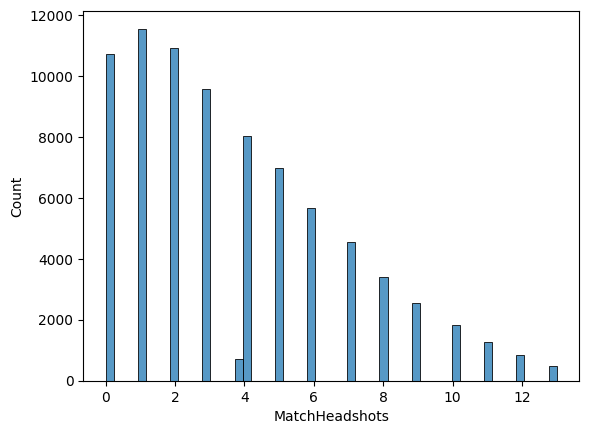

In [ ]:
sns.histplot(df['MatchHeadshots'])

A partir de este gráfico, se puede afirmar que la cantidad de kills por headshots mantiene se sesgo hacia la derecha y tiene una gran concentración de datos alrededor de 1 headshot por partida.  

A partir de esta segunda exploración, podemos afirmar que la imputación de los outliers tuvo un impacto mínimo en el resto de datos dado que fue una cantidad de datos tan pequeña del total de datos(alrededor de un 3%)

### Cálculo del coef. de correlación

In [ ]:
# Creación de objeto Label encoder
label_encoder = LabelEncoder()

# Primero, se transformará las variable "mapa" por ser categórica, usando label encoding de sklearn para que sean consideradas numerica
df["Map"] = label_encoder.fit_transform(df["Map"])

# Transformación de columnas númericas de tipo object
df['TravelledDistance']= df['TravelledDistance'].str.replace('[^\d]', '', regex=True).astype(float)
df['FirstKillTime']= df['FirstKillTime'].str.replace('[^\d]', '', regex=True).astype(float)

<Axes: >

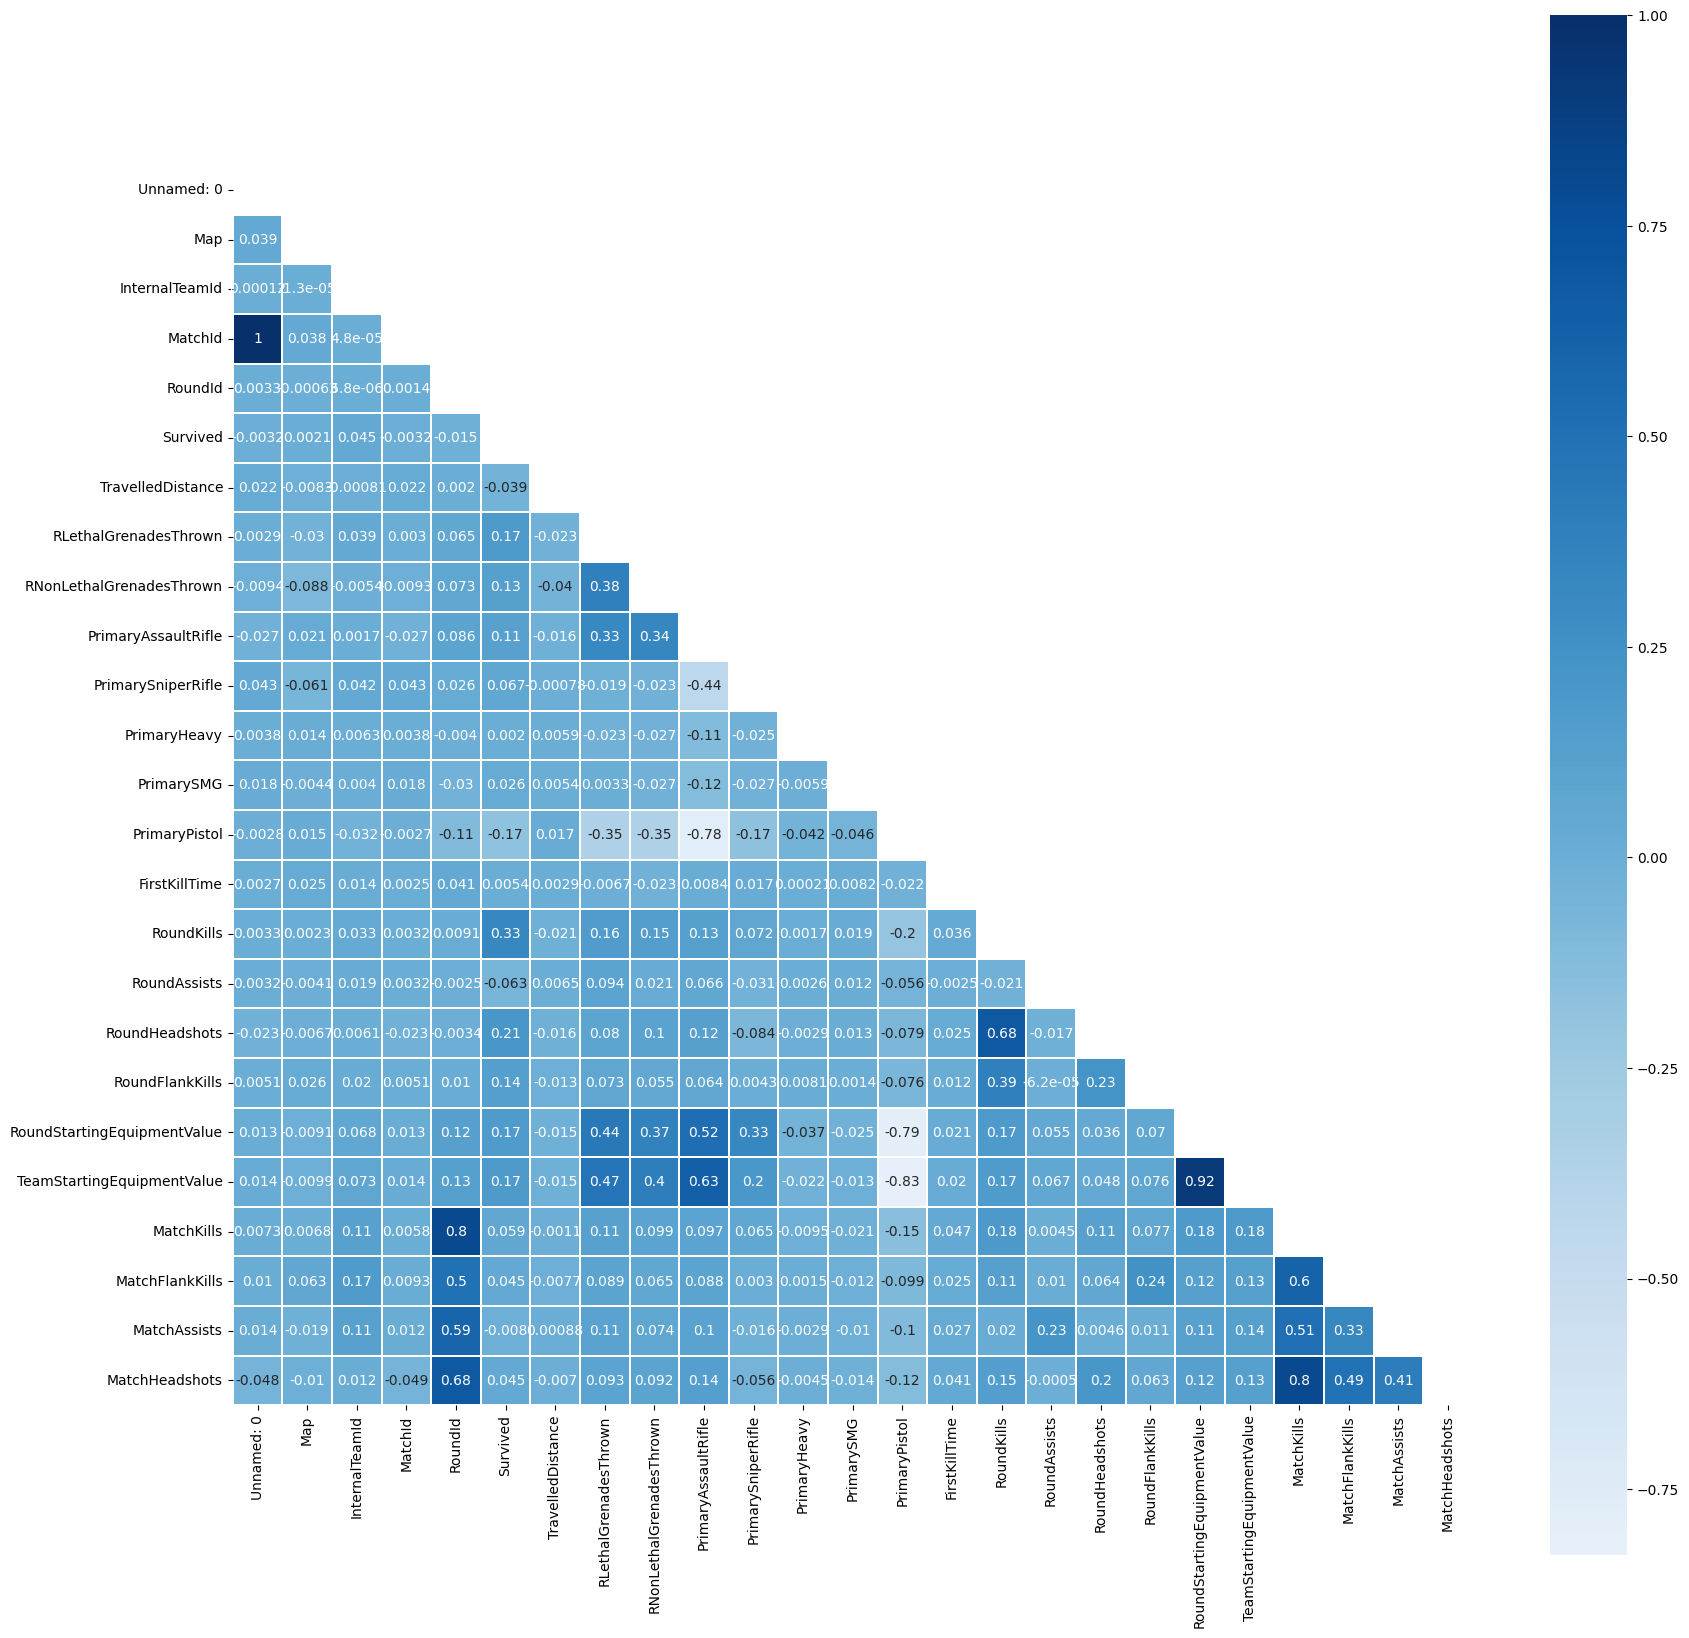

In [ ]:
columnas_para_mapa = df.select_dtypes(include=["int64", "float64", "bool"])
# Se borra la columna AbnormalMatch del mapa ya que no aparece por que solo tiene valores False
columnas_para_mapa = columnas_para_mapa.drop(columns=["AbnormalMatch"])
corr = columnas_para_mapa.corr()

mask=np.triu(np.ones_like(corr, dtype=bool))
#Tamaño del grafico
f, ax = plt.subplots(figsize=(20, 20))
#Configuraciones del mapa de calor
sns.heatmap(corr, mask=mask, cmap='Blues', vmax=1, center=0, square=True, linewidths=.1, annot=True)

De este mapa de calor, concluimos que utilizaremos las variables MatchKills, MatchFlanKills y MatchHeadshots ya que MatchKills tiene una alta correlación con MatchFlanKills y MatchHeadshots y del análisis de estas variables podemos responder la pregunta que planteamos al inicio de este informe para encontrar el estilo de juego que de mejores resultados, o en este caso, que lleve a lograr una mayor cantidad de kills y una mayor probabilidad de ganar la partida.


In [ ]:
print('Correlación Pearson (kills por headshot por partida y total de kills por partida): ', df['MatchHeadshots'].corr(df['MatchKills']))
print('Correlación Pearson (kills por flanqueo por partida y total de kills por partida): ', df['MatchFlankKills'].corr(df['MatchKills']))

Correlación Pearson (kills por headshot por partida y total de kills por partida):  0.8020867612453376
Correlación Pearson (kills por flanqueo por partida y total de kills por partida):  0.6039205477563635


<Axes: xlabel='MatchHeadshots', ylabel='MatchKills'>

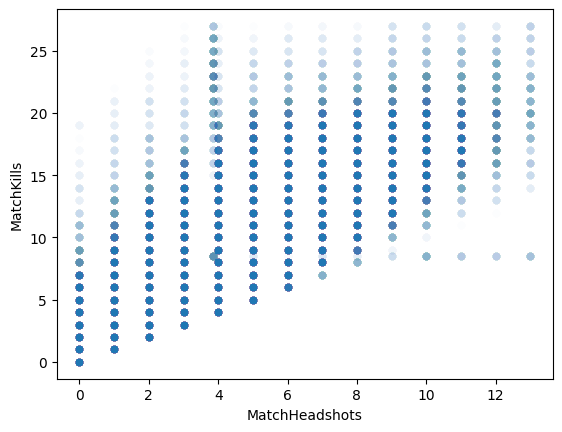

In [ ]:
scatterplot(data=df, x="MatchHeadshots", y="MatchKills", alpha=0.01)
# Se le aplicó cierta transparencia a los siguientes gráficos para visualizar mejor donde hay mayor concentración de los datos.

<Axes: xlabel='MatchFlankKills', ylabel='MatchKills'>

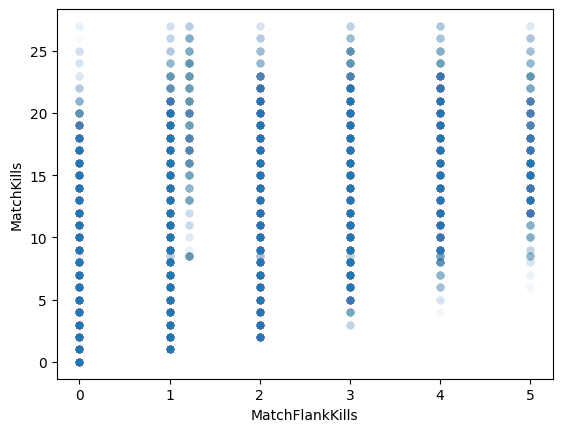

In [ ]:
scatterplot(data=df, x="MatchFlankKills", y="MatchKills", alpha=0.01)

\A partir de los valor de correlación de Pearson y (en menor medida) los gráficos de dispersión podemos afirmar que hay una correlación directa moderada entre kills por flanqueo por partida y total de kills por partida y una correlación directa fuerte entre kills por headshot por partida y total de kills por partida

### Estandarización

A continuación se usará StandardScaler de sklearn para estandarizar los datos y que tengan una media de 0 y desviación standar de 1, esto se hará ya que es requerido para la utilización de ciertos modelos además de mejorar sus resultados.

In [ ]:
scaler = StandardScaler()

columnas = df[["MatchKills", "MatchHeadshots", "MatchFlankKills"]]
scaler.fit(columnas)
columnas_escaladas = scaler.transform(columnas)

# Nuevo dataframe estandarizado
df_escalado = pd.DataFrame(columnas_escaladas, columns=columnas.columns)

In [ ]:
df_escalado.head(10)

,MatchKills,MatchHeadshots,MatchFlankKills
0,-1.390233,-1.230768,-0.887849
1,-1.390233,-1.230768,-0.887849
2,-1.390233,-1.230768,-0.887849
3,-1.390233,-1.230768,-0.887849
4,-1.390233,-1.230768,-0.887849
5,-1.390233,-1.230768,-0.887849
6,-1.390233,-1.230768,-0.887849
7,-1.390233,-1.230768,-0.887849
8,-0.896042,-0.902862,-0.102560
9,-1.060772,-0.574955,-0.887849


In [ ]:
df_escalado["MatchKills"].describe()

NameError: name 'df_escalado' is not defined

<Axes: xlabel='MatchKills', ylabel='Count'>

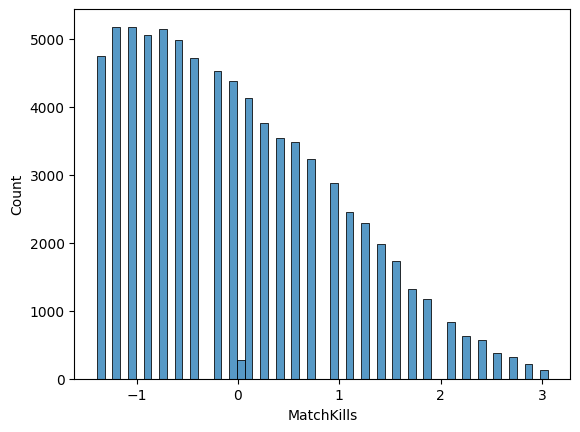

In [ ]:
sns.histplot(df_escalado['MatchKills'])

In [ ]:
df_escalado["MatchHeadshots"].describe()

count    7.915400e+04
mean     2.786372e-16
std      1.000006e+00
min     -1.230768e+00
25%     -9.028616e-01
50%     -2.470488e-01
75%      7.366704e-01
max      3.032015e+00
Name: MatchHeadshots, dtype: float64

<Axes: xlabel='MatchHeadshots', ylabel='Count'>

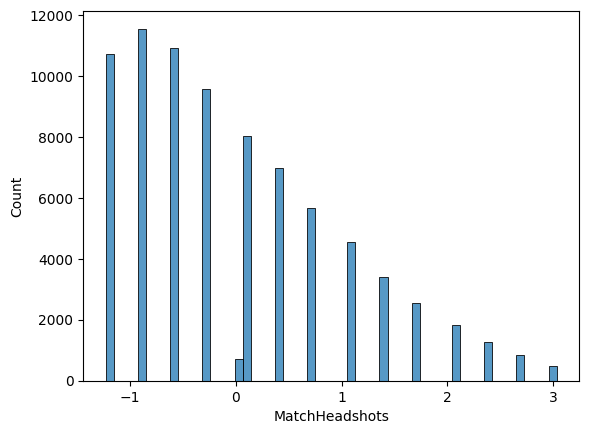

In [ ]:
sns.histplot(df_escalado['MatchHeadshots'])

In [ ]:
df_escalado["MatchFlankKills"].describe()

count    7.915400e+04
mean    -1.757640e-16
std      1.000006e+00
min     -8.878493e-01
25%     -8.878493e-01
50%     -1.025596e-01
75%      6.827301e-01
max      3.038599e+00
Name: MatchFlankKills, dtype: float64

<Axes: xlabel='MatchFlankKills', ylabel='Count'>

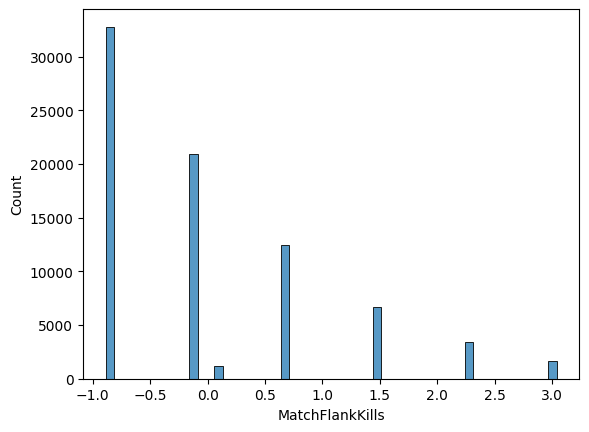

In [ ]:
sns.histplot(df_escalado['MatchFlankKills'])

Con la estandarización se logró llegar a columnas con media 0 y desv. estándar 1 sin distorcionar las diferencias de frecuencia de datos entre los intervalos.

## Fase 4: Modeling (Modelos de regresión)



Para esta fase desarrollaremos los modelos de regresión lineal simple, Lasso y regresión lineal múltiple, utilizando siguientes variables, donde las primeras 2 serán usadas como features y la última, como target:

*   MatchKills (o muertes por partida)
*   MatchHeadshots (o muertes por disparos a la cabeza por partida)
*   MatchFlanKills (o muertes por flanqueo por partida)

Antes de entrenar cada modelo, los datos serán separados en 2 grupos, uno de entrenamiento que que corresponde al 70% del total de los datos y un segundo grupo de prueba con el 30% restante. Después de entrenar el modelo, éste será usado para hacer predicciones con los 2 grupos que fueron separados al comenzar esta etapa. Esto con el objetivo de medir si el modelo realmente aprendió a hacer predicciones con datos nuevos en comparación con los que fueron usados para entrenarlo y así saber si hay overfitting o underfitting


In [1]:
# importaciones
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn import svm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.graph_objects as go


### Modelo 1

Regresión lineal simple 1, MatchHeadshots y MatchKills

In [ ]:
# Para hacer los modelos de regresión, se va a separar el dataframe en un grupo de entrenamiento y un grupo de prueba
Xtrain, Xtest, Ytrain, Ytest= train_test_split(df_escalado['MatchHeadshots'],df_escalado['MatchKills'],test_size=0.3, random_state=20)

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
model = LinearRegression()

model.fit(Xtrain.values.reshape(-1, 1), Ytrain)

LinearRegression()

MAE de los datos de entrenamiento:  0.4496990944502512
MSE de los datos de entrenamiento:  0.3595670027767359
RMSE de los datos de entrenamiento:  0.5996390604161272
R cuadrado de los datos de entrenamiento:  0.6406896680717306
MAE de los datos de prueba:  0.44747380262771064
MSE de los datos de prueba:  0.34987901032588575
RMSE de los datos de prueba:  0.591505714533584
R cuadrado de los datos de prueba:  0.6495274458524944


Text(0.5, 1.0, 'Regresión Lineal')

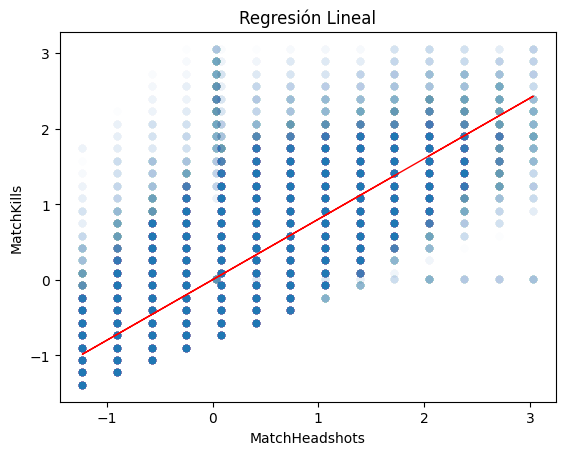

In [ ]:
# Se hacen predicciones usando los datos de prueba y los datos de entrenamiento para saber si el modelo presenta overfitting u overfitting

Y_pred_train = model.predict(Xtrain.values.reshape(-1, 1))
Y_pred_test = model.predict(Xtest.values.reshape(-1, 1))

# Se calculan las métricas comparando los valores reales (Ytest) con los valores predichos (Y_pred_test)

print("MAE de los datos de entrenamiento: ", mean_absolute_error(Ytrain, Y_pred_train))
print("MSE de los datos de entrenamiento: ", mean_squared_error(Ytrain, Y_pred_train))
print("RMSE de los datos de entrenamiento: ", (mean_squared_error(Ytrain, Y_pred_train))**0.5)
print("R cuadrado de los datos de entrenamiento: ", r2_score(Ytrain, Y_pred_train))
print("MAE de los datos de prueba: ", mean_absolute_error(Ytest, Y_pred_test))
print("MSE de los datos de prueba: ", mean_squared_error(Ytest, Y_pred_test))
print("RMSE de los datos de prueba: ", (mean_squared_error(Ytest, Y_pred_test))**0.5)
print("R cuadrado de los datos de prueba: ", r2_score(Ytest, Y_pred_test))

scatterplot(data=df, x=df_escalado['MatchHeadshots'], y=df_escalado['MatchKills'], alpha=0.01)
plt.plot(Xtest, Y_pred_test, color='red', linewidth=1)

plt.title('Regresión Lineal')

### Modelo 2

Regresión lineal simple 2, MatchFlankKills y MatchKills

In [ ]:
# Separación del dataframe en un grupo de entrenamiento y un grupo de prueba
Xtrain, Xtest, Ytrain, Ytest= train_test_split(df_escalado['MatchFlankKills'],df_escalado['MatchKills'],test_size=0.3, random_state=20)

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
model = LinearRegression()

model.fit(Xtrain.values.reshape(-1, 1), Ytrain)

LinearRegression()

In [2]:
# Se hacen predicciones usando los datos de prueba y los datos de entrenamiento para saber si el modelo presenta overfitting u overfitting

Y_pred_train = model.predict(Xtrain.values.reshape(-1, 1))
Y_pred_test = model.predict(Xtest.values.reshape(-1, 1))

# Se calculan las métricas comparando los valores reales (Ytest) con los valores predichos (Y_pred_test)

print("MAE de los datos de entrenamiento: ", mean_absolute_error(Ytrain, Y_pred_train))
print("MSE de los datos de entrenamiento: ", mean_squared_error(Ytrain, Y_pred_train))
print("RMSE de los datos de entrenamiento: ", (mean_squared_error(Ytrain, Y_pred_train))**0.5)
print("R cuadrado de los datos de entrenamiento: ", r2_score(Ytrain, Y_pred_train))
print("MAE de los datos de prueba: ", mean_absolute_error(Ytest, Y_pred_test))
print("MSE de los datos de prueba: ", mean_squared_error(Ytest, Y_pred_test))
print("RMSE de los datos de prueba: ", (mean_squared_error(Ytest, Y_pred_test))**0.5)
print("R cuadrado de los datos de prueba: ", r2_score(Ytest, Y_pred_test))

scatterplot(data=df, x=df_escalado['MatchFlankKills'], y=df_escalado['MatchKills'], alpha=0.01)
plt.plot(Xtest, Y_pred_test, color='red', linewidth=1)

plt.title('Regresión Lineal')

NameError: name 'model' is not defined

### Modelo 3

Lasso 1, MatchHeadshots y MatchKills

In [ ]:
# Para hacer los modelos de regresión, se va a separar el dataframe en un grupo de entrenamiento y un grupo de prueba
Xtrain, Xtest, Ytrain, Ytest= train_test_split(df_escalado['MatchHeadshots'],df_escalado['MatchKills'],test_size=0.3, random_state=20)

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
model = Lasso(alpha=0.1)

model.fit(Xtrain.values.reshape(-1, 1), Ytrain)

Lasso(alpha=0.1)

MAE de los datos de entrenamiento:  0.46523132311833404
MSE de los datos de entrenamiento:  0.36958106702842375
RMSE de los datos de entrenamiento:  0.6079317947174862
R cuadrado de los datos de entrenamiento:  0.6306827521911341
MAE de los datos de prueba:  0.46369903887650865
MSE de los datos de prueba:  0.36047900806503713
RMSE de los datos de prueba:  0.6003990406929688
R cuadrado de los datos de prueba:  0.6389094660024375


Text(0.5, 1.0, 'Lasso')

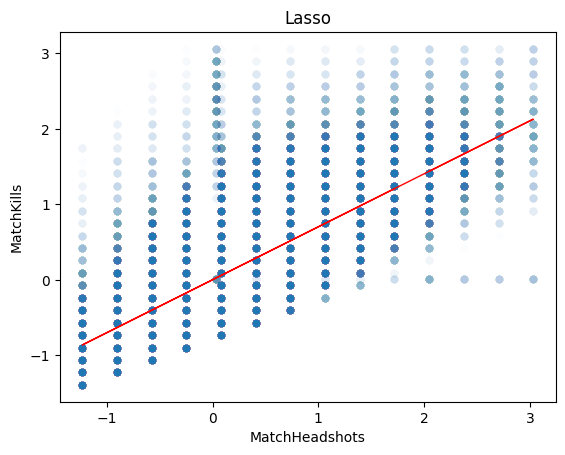

In [ ]:
# Se hacen predicciones usando los datos de prueba y los datos de entrenamiento para saber si el modelo presenta overfitting u overfitting

Y_pred_train = model.predict(Xtrain.values.reshape(-1, 1))
Y_pred_test = model.predict(Xtest.values.reshape(-1, 1))

# Se calculan las métricas comparando los valores reales (Ytest) con los valores predichos (Y_pred_test)

print("MAE de los datos de entrenamiento: ", mean_absolute_error(Ytrain, Y_pred_train))
print("MSE de los datos de entrenamiento: ", mean_squared_error(Ytrain, Y_pred_train))
print("RMSE de los datos de entrenamiento: ", (mean_squared_error(Ytrain, Y_pred_train))**0.5)
print("R cuadrado de los datos de entrenamiento: ", r2_score(Ytrain, Y_pred_train))
print("MAE de los datos de prueba: ", mean_absolute_error(Ytest, Y_pred_test))
print("MSE de los datos de prueba: ", mean_squared_error(Ytest, Y_pred_test))
print("RMSE de los datos de prueba: ", (mean_squared_error(Ytest, Y_pred_test))**0.5)
print("R cuadrado de los datos de prueba: ", r2_score(Ytest, Y_pred_test))

scatterplot(data=df, x=df_escalado['MatchHeadshots'], y=df_escalado['MatchKills'], alpha=0.01)
plt.plot(Xtest, Y_pred_test, color='red', linewidth=1)

plt.title('Lasso')

### Modelo 4

Lasso 2, MatchFlankKills y MatchKills

In [ ]:
# Para hacer los modelos de regresión, se va a separar el dataframe en un grupo de entrenamiento y un grupo de prueba
Xtrain, Xtest, Ytrain, Ytest= train_test_split(df_escalado['MatchFlankKills'],df_escalado['MatchKills'],test_size=0.3, random_state=20)

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
model = Lasso(alpha=0.1)

model.fit(Xtrain.values.reshape(-1, 1), Ytrain)

Lasso(alpha=0.1)

MAE de los datos de entrenamiento:  0.6467720369272852
MSE de los datos de entrenamiento:  0.6443198933666529
RMSE de los datos de entrenamiento:  0.8026953926407282
R cuadrado de los datos de entrenamiento:  0.3561400435364477
MAE de los datos de prueba:  0.6485057023036102
MSE de los datos de prueba:  0.6465409297358109
RMSE de los datos de prueba:  0.8040776888683151
R cuadrado de los datos de prueba:  0.3523622614733114


Text(0.5, 1.0, 'Lasso')

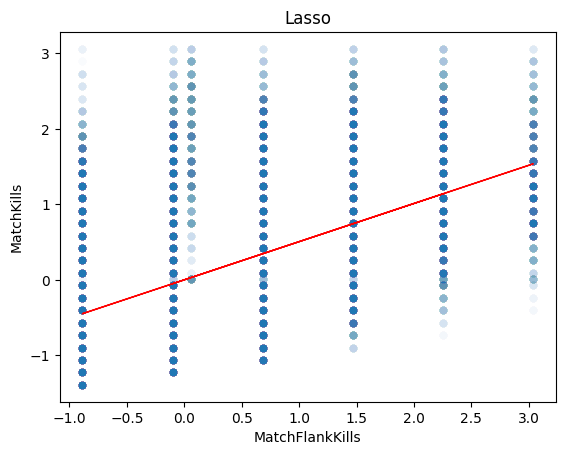

In [ ]:
# Se hacen predicciones usando los datos de prueba y los datos de entrenamiento para saber si el modelo presenta overfitting u overfitting

Y_pred_train = model.predict(Xtrain.values.reshape(-1, 1))
Y_pred_test = model.predict(Xtest.values.reshape(-1, 1))

# Se calculan las métricas comparando los valores reales (Ytest) con los valores predichos (Y_pred_test)

print("MAE de los datos de entrenamiento: ", mean_absolute_error(Ytrain, Y_pred_train))
print("MSE de los datos de entrenamiento: ", mean_squared_error(Ytrain, Y_pred_train))
print("RMSE de los datos de entrenamiento: ", (mean_squared_error(Ytrain, Y_pred_train))**0.5)
print("R cuadrado de los datos de entrenamiento: ", r2_score(Ytrain, Y_pred_train))
print("MAE de los datos de prueba: ", mean_absolute_error(Ytest, Y_pred_test))
print("MSE de los datos de prueba: ", mean_squared_error(Ytest, Y_pred_test))
print("RMSE de los datos de prueba: ", (mean_squared_error(Ytest, Y_pred_test))**0.5)
print("R cuadrado de los datos de prueba: ", r2_score(Ytest, Y_pred_test))


scatterplot(data=df, x=df_escalado['MatchFlankKills'], y=df_escalado['MatchKills'], alpha=0.01)
plt.plot(Xtest, Y_pred_test, color='red', linewidth=1)

plt.title('Lasso')

### Modelo 5

Regresión lineal múltiple, MatchHeadshots y MatchKills

In [ ]:
# Para hacer el modelo de regresión múltiple, se agrupan las 2 variables independientes en una sola variable, llamada XY y se guarda la la variable independiente en Z
XY = df_escalado[['MatchHeadshots', 'MatchFlankKills']]

XYtrain, XYtest, Ztrain, Ztest= train_test_split(XY,df_escalado['MatchKills'],test_size=0.3, random_state=20)

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
modeloRegMultiple = LinearRegression()

modeloRegMultiple.fit(XYtrain, Ztrain)

LinearRegression()

In [ ]:
# Se hacen predicciones usando los datos de prueba y los datos de entrenamiento para saber si el modelo presenta overfitting u overfitting

Z_pred_train = modeloRegMultiple.predict(XYtrain)
Z_pred_test = modeloRegMultiple.predict(XYtest)

# Se calculan las métricas comparando los valores reales (Ztest) con los valores predichos (Z_pred_test)

print("MAE de los datos de entrenamiento: ", mean_absolute_error(Ztrain, Z_pred_train))
print("MSE de los datos de entrenamiento: ", mean_squared_error(Ztrain, Z_pred_train))
print("RMSE de los datos de entrenamiento: ", (mean_squared_error(Ztrain, Z_pred_train))**0.5)
print("R cuadrado de los datos de entrenamiento: ", r2_score(Ztrain, Z_pred_train))
print("MAE de los datos de prueba: ", mean_absolute_error(Ztest, Z_pred_test))
print("MSE de los datos de prueba: ", mean_squared_error(Ztest, Z_pred_test))
print("RMSE de los datos de prueba: ", (mean_squared_error(Ztest, Z_pred_test))**0.5)
print("R cuadrado de los datos de prueba: ", r2_score(Ztest, Z_pred_test))

# Creación del gráfico en 3 dimensiones
xx, yy = np.meshgrid(np.linspace(0, 10, num=10), np.linspace(0, 10, num=10))
nuevoX = (modeloRegMultiple.coef_[0] * xx)
nuevoY = (modeloRegMultiple.coef_[1] * yy)
z = (nuevoX + nuevoY + modeloRegMultiple.intercept_)

# Crear la figura
fig = go.Figure(data=[
    go.Surface(z=z, x=xx, y=yy, colorscale='hot', opacity=0.5, showscale=False)
])

# Configuración de los ejes y el título
fig.update_layout(
    scene=dict(
        xaxis_title='MatchHeadshots',
        yaxis_title='MatchFlankKills',
        zaxis_title='MatchKills'
    ),
    title='Regresión Lineal con Múltiples Variables',
    scene_camera_eye=dict(x=1, y=1, z=1)  # Ajustar los valores según prefieras
)

# Mostrar la figura interactiva
fig.show()

MAE de los datos de entrenamiento:  0.4053950673528972
MSE de los datos de entrenamiento:  0.30032857454914236
RMSE de los datos de entrenamiento:  0.5480224215751964
R cuadrado de los datos de entrenamiento:  0.6998858099451326
MAE de los datos de prueba:  0.40299828926582554
MSE de los datos de prueba:  0.294802616338499
RMSE de los datos de prueba:  0.5429572877662653
R cuadrado de los datos de prueba:  0.7046972728621648


**Tabla comparativa de los modelos**
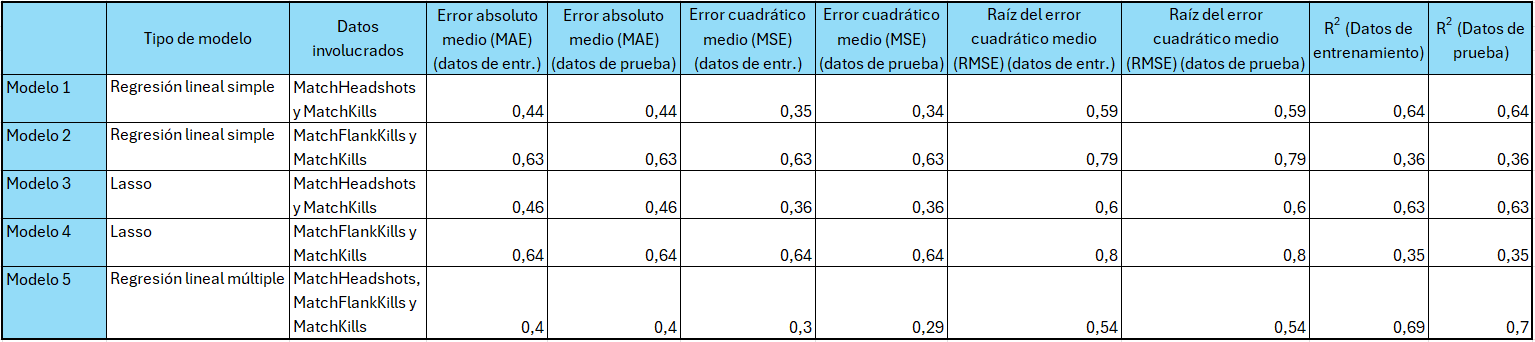



## Fase 5: Evaluation

En conclusión podemos decir que:

* En todos los modelos de regresion lineal se observa una correlación positiva entre las variables MatchHeadshots, MatchFlankKills y MatchKills, es decir, que a medida que aumentan las kills por headshot o flanqueo, también aumentan las kills totales de la partida.
* A partir de la comparación de las métricas podemos afirmar que ninguno de los modelos presenta overfitting, ya que no hay una diferencia significativa entre  las métricas de las predicciones hechas con los datos de entrenamiento y las que fueron hechas con los datos de prueba (la diferencia más grande fue solo de 0.01).
* Como los 2 modelos que involucran la relación entre MatchFlankKills y MatchKills tienen un valor R cuadrado menor a 0.5, (0.36 para el modelo de regresión lineal y 0.35 para el modelo Lasso), por lo que podemos afirmar que presentan underfitting.
* Para finalizar, a partir de la tabla de metricas se extrae que cada modelo tiene diferentes niveles de precisión y efectividad en la predicción de resultados. Como en nuestro caso buscamos el modelo que logre hacer mejores predicciones, el modelo que escogimos es el modelo de regresion lineal múltiple ya que tiene los mejor valores en todas las métricas, teniendo el mayor R cuadrado y el menor valor en el resto de las métricas. Por otro lado, los modelos con las peores métricas fueron los modelos de regresión lineal simple y Lasso que involucran las variables MatchFlankKills y MatchKills (modelos 2 y 4).

## Fase 4: Modeling (Modelos de clasificación)



Para esta fase de clasificación desarrollaremos un arbol de decición y un random forest, utilizando las variables:


*   MatchKills (o muertes por partida)
*   MatchHeadshots (o muertes por disparos a la cabeza por partida)
*   MatchFlanKills (o muertes por flanqueo por partida)

Estas variables fueron elegidas porque, como se mencionó anteriormente, son las que tiene mayor correlación.

Como nuestro target, MatchKills, es una dato numérico, primero lo tendremos que transformar a categórico usando la función cut de Pandas antes de entrenar los modelos.

In [ ]:
# Importaciones necesarias para los modelos de clasificación
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

### Modelo 1

Árbol de decisión

In [ ]:
# Para hacer hacer este modelo de clasificación, se va a separar el dataframe en un grupo de entrenamiento y un grupo de prueba
X = df_escalado[['MatchHeadshots', 'MatchFlankKills']]

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, df_escalado['MatchKills'],test_size=0.3, random_state=20)

# A continuación, se usa la función cut de Pandas para transformar las variables Ytrain e Ytest (que serán usados como targets) a variables categoricas
Ytrain = pd.cut(Ytrain, bins=2, labels = ['bajo', 'alto']  )
Ytest = pd.cut(Ytest, bins=2, labels = ['bajo', 'alto'] )

In [ ]:
#Se entrena el modelo usando reshape ya para que los datos estén en el formato correcto para el modelo
model = DecisionTreeClassifier(max_depth=4)

model.fit(Xtrain, Ytrain)

DecisionTreeClassifier(max_depth=4)

Después de entrenar el modelo, este será usado para hacer predicciones con los 2 grupos que fueron separados al comenzar esta etapa. Esto con el objetivo de medir si el modelo realmente aprendió a hacer predicciones con datos nuevos en comparación con los que fueron usados para entrenarlo y así saber si hay overfitting o underfitting

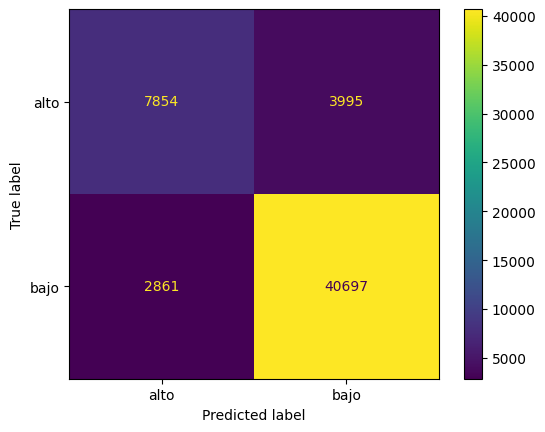

In [ ]:
# Se hacen predicciones usando los datos de entrenamiento
Y_pred_train = model.predict(Xtrain)

matriz_confusion = confusion_matrix(Ytrain, Y_pred_train)

disp = ConfusionMatrixDisplay(matriz_confusion,display_labels=['alto', 'bajo'])
disp.plot()
plt.show()

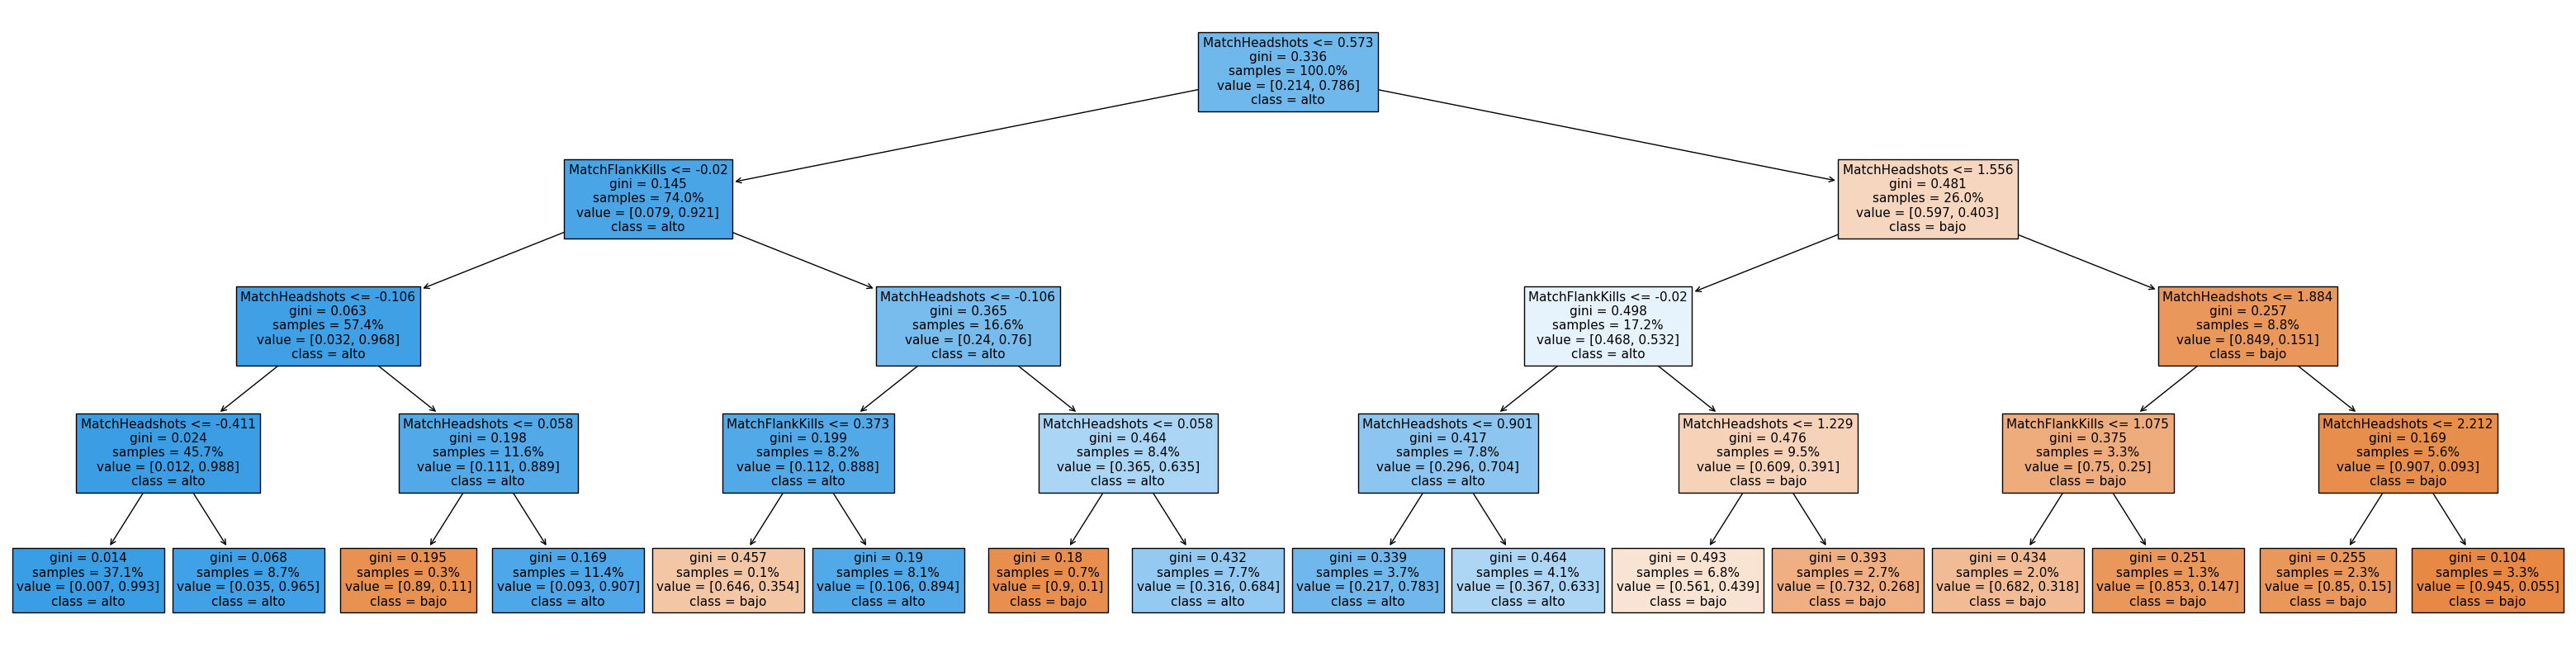

In [ ]:
# Visualización del árbol
plt.figure(figsize = (40,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['bajo', 'alto'],
    label = "all",
    proportion = True,
    filled=True,
    fontsize=11
)
plt.show()

In [ ]:
# Se calculan las métricas con los datos de entrenamiento

print(classification_report(Ytrain,Y_pred_train))

              precision    recall  f1-score   support

        alto       0.73      0.66      0.70     11849
        bajo       0.91      0.93      0.92     43558

    accuracy                           0.88     55407
   macro avg       0.82      0.80      0.81     55407
weighted avg       0.87      0.88      0.87     55407



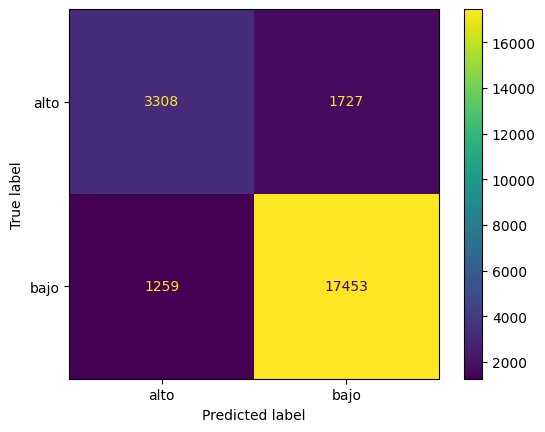

In [ ]:
# Se hacen predicciones usando los datos de prueba
Y_pred_test = model.predict(Xtest)

matriz_confusion = confusion_matrix(Ytest, Y_pred_test)

disp = ConfusionMatrixDisplay(matriz_confusion,display_labels=['alto', 'bajo'])
disp.plot()
plt.show()

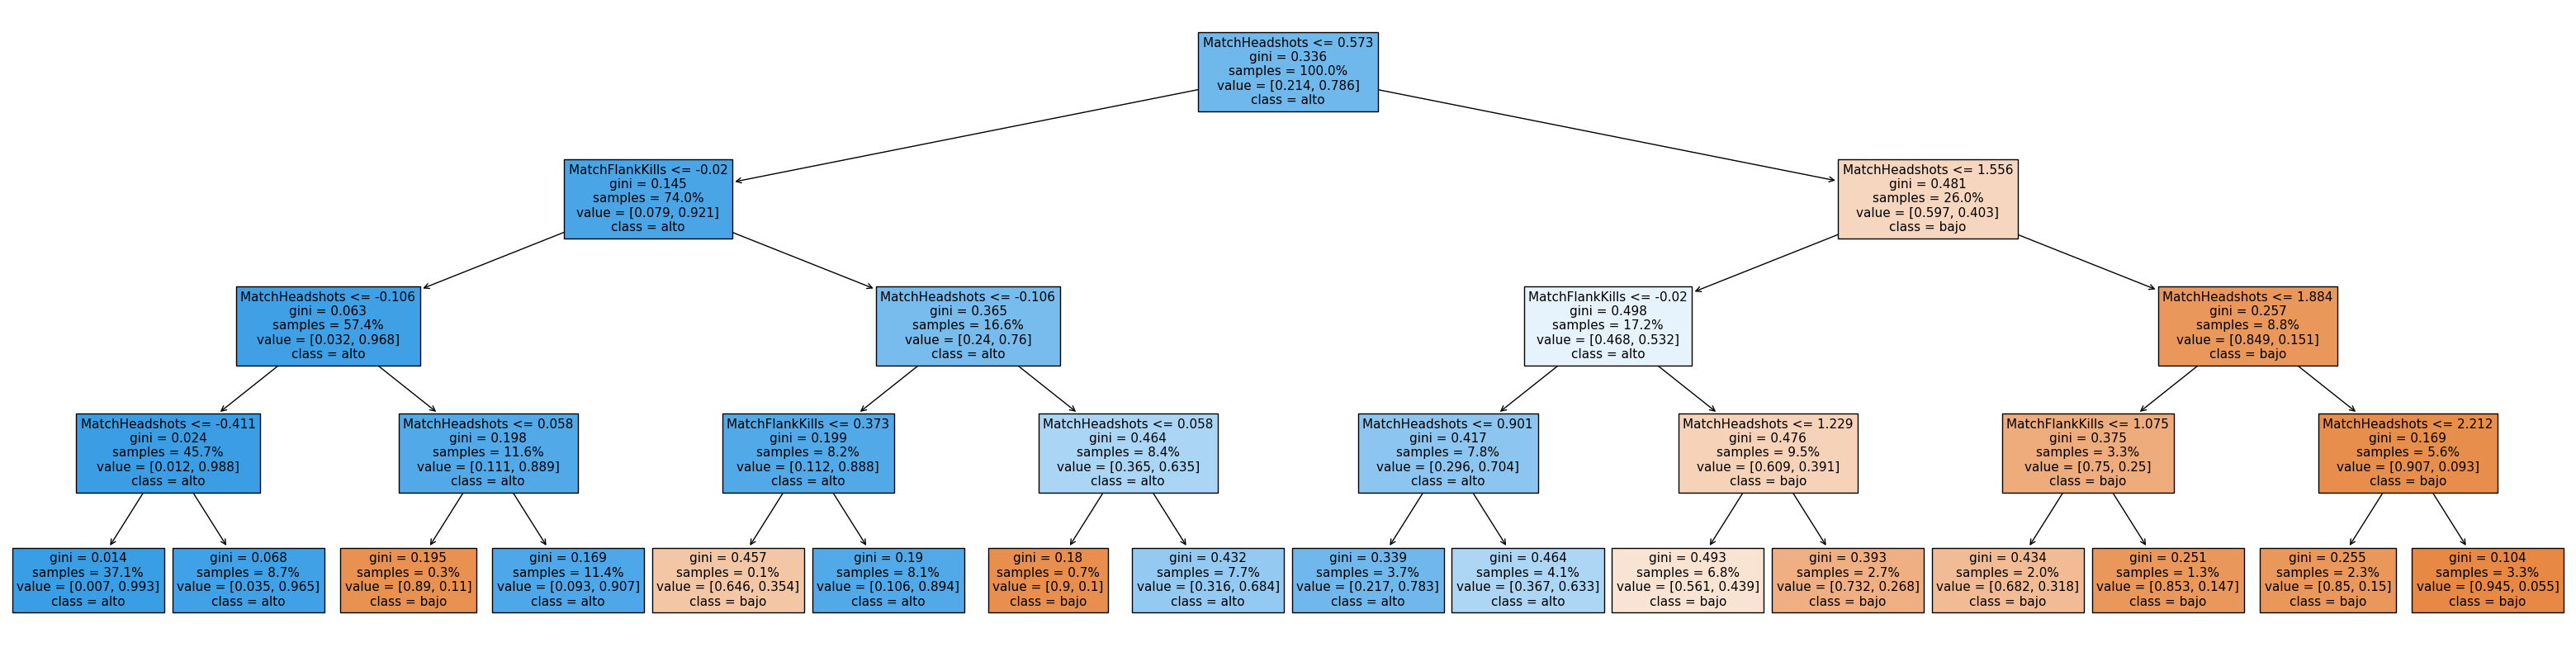

In [ ]:
# Visualización del árbol
plt.figure(figsize = (40,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['bajo', 'alto'],
    label = "all",
    proportion = True,
    filled=True,
    fontsize=11
)
plt.show()

In [ ]:
# Se calculan las métricas con los datos de prueba

print(classification_report(Ytest,Y_pred_test))

              precision    recall  f1-score   support

        alto       0.72      0.66      0.69      5035
        bajo       0.91      0.93      0.92     18712

    accuracy                           0.87     23747
   macro avg       0.82      0.79      0.81     23747
weighted avg       0.87      0.87      0.87     23747



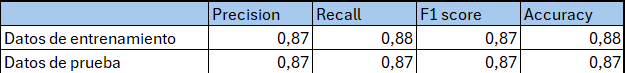

Para este modelo se encontraron buenos resultados, además, no se encontró overfitting porque la diferencia entre las métricas de los datos de prueba y de entrenamiento es de solo 0,01 en todos los parametros, por lo que podemos concluir que no hay overfitting ni underfitting para los datos de prueba y entrenamiento.

### Modelo 2

Random Forest

In [ ]:
# Antes de comenzar este modelo, se va a separar el dataframe en un grupo de entrenamiento y un grupo de prueba
X = df_escalado[['MatchHeadshots', 'MatchFlankKills']]

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, df_escalado['MatchKills'],test_size=0.3, random_state=20)

# A continuación, se usa la función cut de Pandas para transformar las variables Ytrain e Ytest (que serán usados como targets) a variables categoricas
Ytrain = pd.cut(Ytrain, bins=2, labels = ['bajo', 'alto']  )
Ytest = pd.cut(Ytest, bins=2, labels = ['bajo', 'alto'] )

In [ ]:
# Se crea el modelo con 100 arboles
modeloRF = RandomForestClassifier(n_estimators=100, bootstrap = True, verbose=2)

modeloRF.fit(Xtrain, Ytrain)

building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
b

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    1.2s


building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78 of 100
building tree 79 of 100
building tree 80 of 100
building tree 81 of 100
building tree 82 of 100
building tree 83 of 100
building tree 84 of 100
building tree 85

RandomForestClassifier(verbose=2)

Después de entrenar el modelo, al igual como se hizo con el árbol de desición, se harán predicciones ambos grupos que fueron separados al comenzar a trabajar con este modelo para saber si hay overfitting o underfitting.

[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.3s


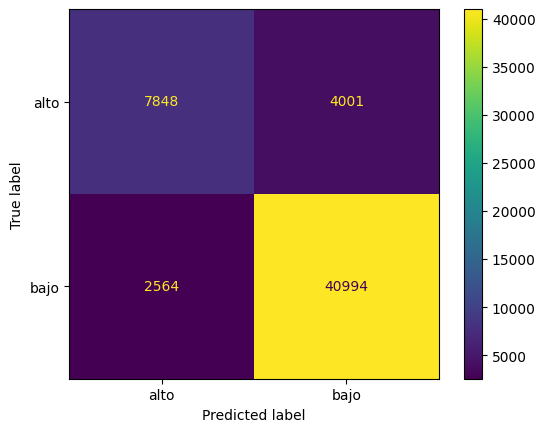

In [ ]:
# Se hacen predicciones usando los datos de entrenamiento
Y_pred_train = modeloRF.predict(Xtrain)

# Matriz de confusión
matriz_confusion = confusion_matrix(Ytrain, Y_pred_train)

disp = ConfusionMatrixDisplay(matriz_confusion,display_labels=['alto', 'bajo'])
disp.plot()

In [ ]:
# Se calculan las métricas con los datos de entrenamiento

print(classification_report(Ytrain, Y_pred_train))

              precision    recall  f1-score   support

        alto       0.75      0.66      0.71     11849
        bajo       0.91      0.94      0.93     43558

    accuracy                           0.88     55407
   macro avg       0.83      0.80      0.82     55407
weighted avg       0.88      0.88      0.88     55407



[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.1s


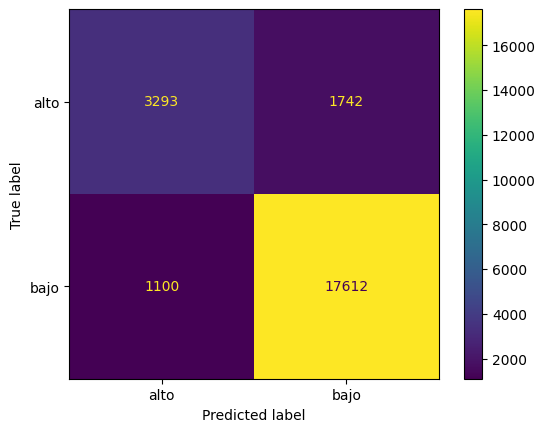

In [ ]:
# Se hacen predicciones usando los datos de prueba
Y_pred_test = modeloRF.predict(Xtest)

# Matriz de confusión
matriz_confusion = confusion_matrix(Ytest, Y_pred_test)

disp = ConfusionMatrixDisplay(matriz_confusion,display_labels=['alto', 'bajo'])
disp.plot()

In [ ]:
# Se calculan las métricas de los datos de prueba

print(classification_report(Ytest, Y_pred_test))

              precision    recall  f1-score   support

        alto       0.75      0.65      0.70      5035
        bajo       0.91      0.94      0.93     18712

    accuracy                           0.88     23747
   macro avg       0.83      0.80      0.81     23747
weighted avg       0.88      0.88      0.88     23747



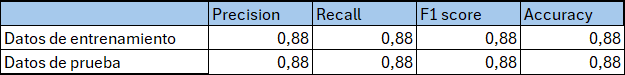

Para este modelo se encontraron muy buenos resultados, por esto podemos decir que no hay underfitting, además, tanto para los datos de prueba y entrenamiento los parametros son absolutamente iguales, por esto podemos concluir que no hay overfitting.



## Fase 5: Evaluation

Tabla comparativa de las métricas para ambos modelos de clasificación

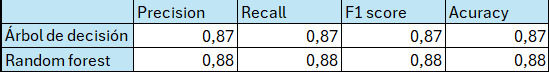

**En conclusión podemos decir que**


No se encontro overfitting y underfitting en ninguno de los modelos.

A partir del análisis de las métricas:
*   Ambos modelos tienen una alta precisión, es decir que cuando predicen que una clase corresponde a "alto", están en lo correcto la gran mayoría de los casos (87% u 88% de los casos dependiedo del modelo).
*   Ambos modelos tienen un alto Recall, lo que significa que de todos los casos "alto" reales, los predicen correctamente la gran mayoría de los casos (87% u 88% de los casos dependiedo del modelo).
*   Al tener un alto f1-score, ambos modelos tienen un gran balance entre precision y recall.
*   Al tener alto Acuracy, quiere decir que, la gran mayoría del total de predicciones en ambos modelos son correctas.


Si bien, ambos modelos tienen un rendimiento muy similar, el random forest presenta un rendimiento ligeramente mejor respecto al árbol de decisión, porque se observa un valor de 0,88 para todos las métricas del modelo, mientras que para el arbol de decisión se oberva un valor de 0,87 para todos las métricas, por lo tanto como equipo escogimos el modelo random forest ya que presenta un mejor desempeño.

## Fase 5: Deployment

Para esta fase de despliegue se realizará la implementación de ambos modelos elegidos en las fases anteriores, el modelo de regresión lineal múltiple y random forest, utilizando las siguientes variables:

*   MatchHeadshots y MatchFlankKills como entrada que serán ingresadas por el usuario.
*   MatchKills como salida, entregada por las predicciones de los modelos




El propósito de esta fase es asegurar que el modelo de machine learning pueda ser utilizado de manera efectiva en un entorno de producción, proporcionando predicciones útiles a partir de datos de entrada en tiempo real.



In [ ]:
#Implementación del modelo de regresión

X = int(input("Ingrese la cantidad de kills que se hizo mediante headshots en la partida: "))
Y = int(input("Ingrese la cantidad de kills que se hizo mediante flanqueo en la partida: "))

entrada = [[X, Y]]

# Se usa standarScaler para escalar los datos entreda ya que esto también se hizo con los datos de entrenamiento del modelo
scaler = StandardScaler()
columnas = df[["MatchHeadshots", "MatchFlankKills"]]
scaler.fit(columnas)
entrada = pd.DataFrame([[X, Y]], columns=['MatchHeadshots', 'MatchFlankKills'])
entrada_escalada = scaler.transform(entrada)
entrada_escalada = pd.DataFrame(entrada_escalada, columns=['MatchHeadshots', 'MatchFlankKills'])

#Se hace la predicción usando el modelo
prediccion_escalada = modeloRegMultiple.predict(entrada_escalada)

# Se desescala la predicción
scaler = StandardScaler()
columnas = df["MatchKills"]
scaler.fit(columnas.values.reshape(-1, 1))
prediccion = str(scaler.inverse_transform(prediccion_escalada.reshape(-1, 1)))

print("Se predice que logró este total de kills en la partida: " + prediccion)

Ingrese la cantidad de kills que se hizo mediante headshots en la partida: 4
Ingrese la cantidad de kills que se hizo mediante flanqueo en la partida: 2
Se predice que logró este total de kills en la partida: [[9.93137622]]


In [ ]:
#Implementación del modelo de clasificación

X = int(input("Ingrese la cantidad de kills que se hizo mediante headshots en la partida: "))
Y = int(input("Ingrese la cantidad de kills que se hizo mediante flanqueo en la partida: "))

entrada = [[X, Y]]

# Se usa standarScaler para escalar los datos entreda ya que esto también se hizo con los datos de entrenamiento del modelo
scaler = StandardScaler()
columnas = df[["MatchHeadshots", "MatchFlankKills"]]
scaler.fit(columnas)
entrada = pd.DataFrame([[X, Y]], columns=['MatchHeadshots', 'MatchFlankKills'])
entrada_escalada = scaler.transform(entrada)
entrada_escalada = pd.DataFrame(entrada_escalada, columns=['MatchHeadshots', 'MatchFlankKills'])

#Se hace la predicción usando el modelo
prediccion = modeloRF.predict(entrada_escalada)
# Como la prediccion de este modelo no es numérica, no es necesario desescalarla


print("Se predice que logró un total " + prediccion + " de kills en la partida")

Ingrese la cantidad de kills que se hizo mediante headshots en la partida: 0
Ingrese la cantidad de kills que se hizo mediante flanqueo en la partida: 9
['Se predice que logró un total alto de kills en la partida']


[Parallel(n_jobs=1)]: Done  40 tasks      | elapsed:    0.0s


En base a los resultados obtenidos de ambos modelos y para responder a la pregunta planteada inicialmente, podemos concluir que ambos estilos de juego, priorizar flanqueos o headshots, dan resultados similares, por lo que ningún estilo de juego es significativamente mejor que el otro y se recomienda que cada jugador escoja el estilo de juego que más le acomode si se busca lograr el mayor total de kills posible. Esto se evidencia si se introducen valores solo en un tipo de kills y se introduce 0 en el otro (ej: 8 kills mediante headshot y 0 por flanqueo), ya que ambos modelos predicen resultados prácticamente iguales, solo con diferencias marginalmente a favor del número de flanqueos logrados, como se puede ver en las imagenes a continuación.

**Modelo de regresión:**


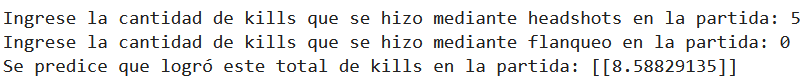


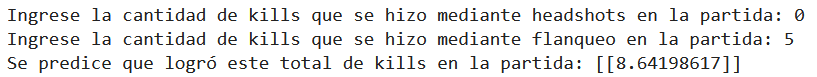

**Modelo de clasificación:**

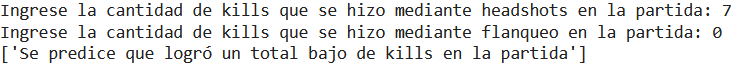

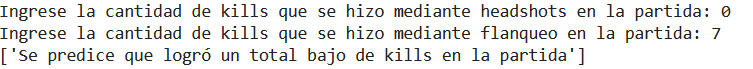

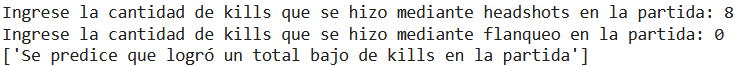


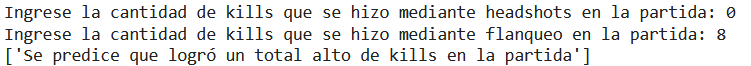


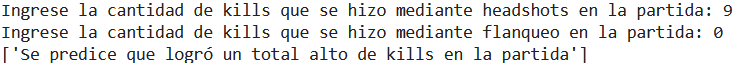

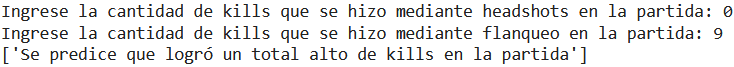